In [1]:
!pip install -q transformers timm peft accelerate

In [2]:
!pip install -q transformers timm pytesseract
!apt-get -qq install -y tesseract-ocr

In [3]:
import shutil

# Keep this in sync with CFG.experiment_tag in the next cell -- out_dir is
# now "cardiovlm_ckpt_<experiment_tag>", so this only deletes the CURRENT
# variant's checkpoint, not other architecture comparisons you may want to
# keep around for the Results section.
EXPERIMENT_TAG = "combo234_vit_base_patch"   # <-- CHANGE THIS to match CFG.experiment_tag below
shutil.rmtree(f"/kaggle/working/cardiovlm_ckpt_{EXPERIMENT_TAG}", ignore_errors=True)


In [5]:
"""
CardioVLM — Paired Rhythm + Beat Report Pipeline
=====================================================================================
Your dataset has TWO files per patient (confirmed from uploaded samples, ID "09"):
  - "<id>_12 channel report.jpg"  -> full 12-lead rhythm strip + diagnosis text
  - "<id>_Beat report.jpg"        -> per-lead numeric table + a REAL representative
                                     beat waveform montage (12 small traces, grid layout)

This replaces the earlier "fake beat" version (which cropped a random lead-II
strip out of the rhythm image as a stand-in). Now:
  1. Files are PAIRED by patient ID, normalizing filename inconsistencies
     (e.g. "1,032" / "1_015" / "09" all become plain digit strings).
  2. `ecg_image`  = the 12-lead grid, cropped from the rhythm report (unchanged).
  3. `beat_image` = the actual 12-panel beat waveform montage, cropped from the
     beat report (the real modality, not a proxy).
  4. Numeric fields (HR/PR/QRS/QT/QTc/axes) are OCR'd from the beat report's
     left-column header FIRST (tested to be more reliable, including axes),
     falling back to the rhythm report's header if any field is missing there.
  5. Diagnosis text/labels still come from the rhythm report's "Analysis
     Result" column — it's the only file that has it.

Install once at top of a Kaggle notebook cell:
    !pip install -q transformers timm pytesseract
    !apt-get -qq install -y tesseract-ocr
"""

import os
import re
import glob
import random
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageOps
import torchvision.transforms as T

try:
    import pytesseract
except ImportError:
    os.system("pip install -q pytesseract")
    import pytesseract

try:
    import timm
except ImportError:
    os.system("pip install -q timm")
    import timm

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers.modeling_outputs import BaseModelOutput


# ---------------------------------------------------------------------------
# 0. CONFIG
# ---------------------------------------------------------------------------

class CFG:
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"

    raw_image_dir = "/kaggle/input/datasets/afrinakterafrinakter/1dataset/1(dataset)"  # <-- CHANGE IF NEEDED
    metadata_csv = "/kaggle/working/ecg_metadata_paired_5k.csv"

    img_size = 384    # was 224 — RBBB/ICRBBB (F1=0.000-0.13 despite 90-99 training
                        # examples, consistent across two runs) depend on a subtle
                        # V1 notch pattern that likely gets destroyed when a
                        # 1280x830 grid is squeezed down to 224x224. 384 preserves
                        # more of that fine detail at a manageable compute cost.
    num_numeric_features = 9    # hr, pr, qrs, qt, qtc, axes_missing
    fusion_dim = 256
    fusion_heads = 4
    transformer_layers = 2

    # ====================================================================
    # ARCHITECTURE COMPARISON — change ONE of these three lines per run,
    # then change experiment_tag below to match, to compare encoder/decoder
    # choices for the Results section without overwriting previous results.
    # ====================================================================
    rhythm_encoder_name = "vit_base_patch16_224"   # 12-lead rhythm image encoder
    # Alternatives to try (all free, pretrained, via timm):
    #   "vit_base_patch16_224"   — larger ViT, ~3x the parameters, likely
    #                              slower/more prone to overfitting on 2,500
    #                              patients but may capture finer detail
    #   "vit_small_patch16_224.dino"  — same size, DINO self-supervised
    #                              pretraining instead of supervised ImageNet
    #   "convnext_tiny"          — convolutional instead of attention-based;
    #                              a genuinely different inductive bias, not
    #                              just a bigger/smaller version of the same idea

    beat_encoder_name = "resnet18"   # beat-morphology image encoder
    # Alternatives to try (all free, pretrained, via timm):
    #   "resnet34"               — deeper ResNet, same family
    #   "efficientnet_b0"        — different architecture family, similar size
    #   "vit_small_patch16_224"  — same encoder type as the rhythm image,
    #                              in case a matched pair of ViTs behaves
    #                              differently than a ViT+CNN mix

    decoder_name = "google/flan-t5-small"   # report-generation decoder
    # Alternatives to try (all free, via transformers):
    #   "google/flan-t5-base"    — larger flan-T5, ~3x the parameters
    #   "t5-small"               — same size, no instruction-tuning (flan-T5
    #                              is T5 + instruction tuning on top)
    #   "facebook/bart-base"     — different pretraining objective entirely
    #                              (denoising autoencoder vs. T5's span
    #                              corruption), genuinely different decoder,
    #                              not just a different size of the same one

    experiment_tag = "combo234_vit_base_patch"   # <-- CHANGE THIS to match whichever
    # line above you changed, e.g. "vit_base_rhythm", "efficientnet_beat",
    # "flant5_base_decoder". This becomes part of out_dir below, so each
    # variant's checkpoint/splits/thresholds land in their own folder instead
    # of overwriting the previous run's — without this, comparing architecture
    # variants would silently compare a variant against ITSELF (whatever
    # trained last), not against the baseline.
    # ====================================================================

    max_report_len = 64

    batch_size = 8
    epochs = 15
    # Checkpoint selection is driven by classification macro_f1 alone (see
    # below) — but the decoder converges more slowly than the classifier, and
    # how much slower isn't fixed: it depends on dataset size/composition. On
    # the smaller dataset both converged around the same timescale (15 epochs,
    # never early-stopped) and this was never a problem. On the larger dataset
    # classification saturated fast (best macro_f1 at epoch 3, early-stopped at
    # epoch 7) while report_loss was still 0.36 at epoch 3 vs 0.13 by epoch 8 —
    # freezing "best" at epoch 3 locked in an undertrained decoder, and
    # "Normal Axis" dropped out of generated reports again as a direct result,
    # even though the decoder LR fix itself was still working correctly.
    # This floor stops a checkpoint from being frozen as "best" before the
    # decoder has had a baseline number of steps, regardless of how fast
    # classification alone converges.
    min_decoder_epochs = 8
    lr = 2e-4
    decoder_lr = 1e-4
    cls_loss_weight = 1.0
    report_loss_weight = 0.15   # report_loss runs ~30-50x larger than cls_loss;
                                 # equal weighting let it dominate gradients and
                                 # destabilize the classifier (see exact_match
                                 # dropping to 0.159 at epoch 4 in the unweighted run)

    # report_loss_weight above exists to protect the SHARED backbone (image/beat/
    # numeric encoders, fusion, transformer) from being swamped by report_loss —
    # but decoder-only parameters get ZERO gradient from cls_loss, so scaling
    # their gradient by report_loss_weight too doesn't balance anything for them,
    # it just shrinks their effective LR to decoder_lr * report_loss_weight =
    # 1e-4 * 0.15 = 1.5e-5. That's a very small update rate for a pretrained LM
    # that needs to learn new cross-attention behavior in ~500 total training
    # steps, and is the most likely reason the decoder converged to a near-
    # input-independent output regardless of two prior (disproven) fixes.
    # Compensating here restores the decoder's effective LR back to decoder_lr.
    effective_decoder_lr = decoder_lr / report_loss_weight

    out_dir = f"/kaggle/working/cardiovlm_ckpt_{experiment_tag}"

    # 3-way split: train (fit the model) / val (checkpoint selection + threshold
    # tuning — used repeatedly during development) / test (touched EXACTLY ONCE,
    # at the very end, for the numbers that go in the paper). Previously this
    # was a single 80/20 split doing all three jobs at once — that's data
    # leakage: the reported macro_f1/F1 were optimistic because the same val
    # data influenced both which checkpoint got picked AND which threshold got
    # picked AND was what got reported as "performance."
    train_frac = 0.70
    val_frac = 0.15
    # test_frac is whatever remains (~0.15)

    # k-fold calibration (separate from the main train/val run above, which
    # still produces the deployed checkpoint). Purpose: get reliable per-label
    # thresholds/F1 for rare conditions. A single 80/20 split gives ICRBBB-tier
    # classes only ~4-9 held-out examples (e.g. Anteroseptal MI, ST abnormality,
    # RVH) — a tuned threshold from that few points is fitting noise, not a real
    # decision boundary (this is why the last run's tuned Inferior MI threshold
    # of 0.80 still let a 0.801 false positive through on a normal patient).
    # 5-fold CV pools every patient's out-of-fold prediction once, giving each
    # rare class ~its full dataset count worth of held-out evaluations instead
    # of a random 20% slice of it.
    cv_folds = 5
    cv_epochs = 8            # lighter than the main run's 15 — these folds only
                               # need to be good enough for threshold/F1 estimates,
                               # not to produce a deployed model
    min_pooled_support_for_tuning = 15   # below this, a "tuned" threshold is
                                            # noise fitting; fall back to 0.5 and
                                            # flag it as a data limitation instead


NUMERIC_COLS = [
    "hr",
    "pr",
    "qrs",
    "qt",
    "qtc",
    "p_axis",
    "qrs_axis",
    "t_axis",
    "axes_missing",
]
CONDITION_VOCAB = [
    "Normal Sinus Rhythm", "Normal Axis", "Normal ECG",
    "ICRBBB",   # LBBB dropped: only 2 examples in the whole dataset (last run's
                # pos_weight printout) — can't be trained or evaluated
    "Atrial Fibrillation",   # "AFib" alias dropped: 0 occurrences — the OCR'd
                              # text always spells this out, never abbreviates
    "Sinus Bradycardia", "Sinus Tachycardia",
    "Left Axis Deviation", "Right Axis Deviation",
    # "First Degree AV Block" and generic "Myocardial Infarction" (the literal
    # phrase) dropped: 0 train_support in the last run — they never appear
    # verbatim in the OCR'd diagnosis text, so they were pure dead columns.
    "Inferior MI", "Anteroseptal MI",   # kept — 34 and 5 train examples, usable
    "MI",   # generic catch-all; also now absorbs "Lateral MI"/"Posterior MI"
            # text (1 example each — too few to be their own trainable class,
            # but the word "MI" still appears in that text so they still count
            # toward this bucket, per the cell7/8 fix's original reasoning)
    "ST abnormality", "Markedly Abnormal ECG",
    "LVH", "RVH", "PVC",
    "Low Voltage", "PAC",
]


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CFG.seed)
os.makedirs(CFG.out_dir, exist_ok=True)


# ---------------------------------------------------------------------------
# 1. FILE PAIRING
#    Handles the ID-format inconsistency seen across your files
#    ("1,032_12_channel_report.jpg", "1_015_12_channel_report.jpg",
#     "09_12 channel report.jpg", "09_Beat report.jpg", ...)
# ---------------------------------------------------------------------------

RHYTHM_SUFFIX_RE = re.compile(r"^(.*?)[_,]?12[_ ]?channel[_ ]?report\.(jpg|jpeg|png)$", re.IGNORECASE)
BEAT_SUFFIX_RE = re.compile(r"^(.*?)[_,]?beat[_ ]?report\.(jpg|jpeg|png)$", re.IGNORECASE)


def normalize_patient_id(raw):
    """Strips separators (',', '_', ' ') so '1,032' / '1_015' / '09' become
    comparable digit strings regardless of formatting quirks."""
    digits = re.sub(r"\D", "", raw)
    digits = digits.lstrip("0") or "0"
    return digits


def find_patient_pairs(image_dir):
    files = sorted(glob.glob(os.path.join(image_dir, "*.jpg")) +
                    glob.glob(os.path.join(image_dir, "*.jpeg")) +
                    glob.glob(os.path.join(image_dir, "*.png")))
    if not files:
        raise FileNotFoundError(f"No image files found in {image_dir}")

    rhythm_map, beat_map = {}, {}
    unmatched = []
    for path in files:
        base = os.path.basename(path)
        m_rhythm = RHYTHM_SUFFIX_RE.match(base)
        m_beat = BEAT_SUFFIX_RE.match(base)
        if m_rhythm:
            pid = normalize_patient_id(m_rhythm.group(1))
            rhythm_map[pid] = path
        elif m_beat:
            pid = normalize_patient_id(m_beat.group(1))
            beat_map[pid] = path
        else:
            unmatched.append(base)

    paired_ids = sorted(set(rhythm_map) & set(beat_map))
    pairs = [{"patient_id": pid, "rhythm_path": rhythm_map[pid], "beat_path": beat_map[pid]}
              for pid in paired_ids]

    only_rhythm = set(rhythm_map) - set(beat_map)
    only_beat = set(beat_map) - set(rhythm_map)
    print(f"Paired: {len(pairs)} patients | "
          f"rhythm-only (no beat file found): {len(only_rhythm)} | "
          f"beat-only (no rhythm file found): {len(only_beat)} | "
          f"unmatched filenames: {len(unmatched)}")
    if unmatched:
        print("First few unmatched filenames (check naming pattern):", unmatched[:5])

    return pairs


# ---------------------------------------------------------------------------
# 2. IMAGE CROPPING (verified against your uploaded 1280x960 samples)
# ---------------------------------------------------------------------------

def crop_rhythm_regions(image_path):
    im = Image.open(image_path).convert("RGB")
    w, h = im.size
    header = im.crop((0, 0, w, int(h * 0.12)))
    # x-start moved to 9% (measured precisely: label glyphs span pixel columns
    # 55-95 out of 1280 width = 4.3%-7.4%, NOT 0-40px as originally assumed —
    # the earlier 4% cut sliced through the START of the labels instead of
    # past them, which is why they were still fully visible in the overlay).
    # 9% clears the measured range with margin. Verified visually before use.
    grid = im.crop((int(w * 0.09), int(h * 0.12), w, int(h * 0.984)))
    return {"header": header, "grid": grid}


def crop_beat_regions(image_path):
    im = Image.open(image_path).convert("RGB")
    w, h = im.size
    # left-column header block: ID/Name/Age/HR/PR/QRS/QT-QTc/axes — verified clean OCR
    left_header = im.crop((0, int(h * 0.026), int(w * 0.2), int(h * 0.25)))
    # 12-panel beat waveform montage, below the numeric table
    grid = im.crop((0, int(h * 0.396), w, int(h * 0.984)))
    return {"left_header": left_header, "grid": grid}


# ---------------------------------------------------------------------------
# 3. OCR PARSING
#    Same field labels appear on BOTH rhythm and beat headers, so one parser
#    works for either crop. Beat-report header is tried first (cleaner OCR,
#    verified on your samples), rhythm header fills in anything missing.
# ---------------------------------------------------------------------------

def _prep_for_ocr(img, scale=3):
    img = img.convert("L")
    img = img.resize((img.width * scale, img.height * scale), Image.LANCZOS)
    return ImageOps.autocontrast(img)

def parse_numeric_block(img):
    text = pytesseract.image_to_string(
        _prep_for_ocr(img),
        config="--psm 6"
    )

    # সাময়িকভাবে OCR output দেখার জন্য
   # print("OCR NUMERIC TEXT:")
    #print(repr(text))
    #print("-" * 50)

    def find_num(pattern, default=np.nan):
        m = re.search(pattern, text, re.IGNORECASE)
        return float(m.group(1)) if m else default

    hr = find_num(
        r"Heart\s*Rate\s*:?\s*[:\.]?\s*(\d{2,3})"
    )
    pr = find_num(
        r"PR\s*int\.?\s*:?\s*(\d{2,3})"
    )
    qrs = find_num(
        r"QRS\s*dur\.?\s*:?\s*(\d{2,3})"
    )

    qt_qtc = re.search(
        r"(\d{2,3})\s*/\s*(\d{2,3})",
        text
    )
    qt = float(qt_qtc.group(1)) if qt_qtc else np.nan
    qtc = float(qt_qtc.group(2)) if qt_qtc else np.nan

    axes_match = re.search(
        r"(?:P\s*[-/]?\s*R\s*[-/]?\s*T|PRT)"
        r"\s*axes?\s*[:;*]?\s*"
        r"(-?\d{1,3})\s*[-–]\s*"
        r"(-?\d{1,3})\s*[-–]\s*"
        r"(-?\d{1,3})",
        text,
        re.IGNORECASE
    )
    if axes_match:
        p_axis = float(axes_match.group(1))
        qrs_axis = float(axes_match.group(2))
        t_axis = float(axes_match.group(3))
        axes_missing = 0.0
    else:
        p_axis = np.nan
        qrs_axis = np.nan
        t_axis = np.nan
        axes_missing = 1.0

    return {
        "hr": hr,
        "pr": pr,
        "qrs": qrs,
        "qt": qt,
        "qtc": qtc,
        "p_axis": p_axis,
        "qrs_axis": qrs_axis,
        "t_axis": t_axis,
        "axes_missing": axes_missing,
    }

def parse_diagnosis(rhythm_header_img, w):
    result_crop = rhythm_header_img.crop((int(w * 0.375), 0, int(w * 0.72), rhythm_header_img.height))
    text = pytesseract.image_to_string(_prep_for_ocr(result_crop), config="--psm 6")

    labels = np.zeros(len(CONDITION_VOCAB), dtype=np.float32)
    text_lower = text.lower()
    for i, cond in enumerate(CONDITION_VOCAB):
        # word-boundary match, not plain substring — "mi" as a plain substring
        # was matching inside "Minimally" (Minimally Abnormal appears in most
        # records), causing widespread false-positive MI labels
        if re.search(r"\b" + re.escape(cond.lower()) + r"\b", text_lower):
            labels[i] = 1.0
    return labels, text.strip().replace("\n", " ")


def parse_patient_record(rhythm_path, beat_path):
    rhythm_regions = crop_rhythm_regions(rhythm_path)
    beat_regions = crop_beat_regions(beat_path)

    primary = parse_numeric_block(beat_regions["left_header"])      # tried first
    fallback = parse_numeric_block(rhythm_regions["header"])         # fills gaps

    merged = {}

    for k in [
        "hr",
        "pr",
        "qrs",
        "qt",
        "qtc",
        "p_axis",
        "qrs_axis",
        "t_axis",
    ]:
        merged[k] = (
            primary[k]
            if not np.isnan(primary[k])
            else fallback[k]
        )

    merged["axes_missing"] = min(
        primary["axes_missing"],
        fallback["axes_missing"]
    )
    labels, raw_text = parse_diagnosis(rhythm_regions["header"], rhythm_regions["header"].width)
    merged["labels"] = labels
    merged["raw_result_text"] = raw_text
    return merged


# ---------------------------------------------------------------------------
# 4. BUILD METADATA CSV (run ONCE)
# ---------------------------------------------------------------------------

def build_metadata_csv(image_dir, out_csv):
    pairs = find_patient_pairs(image_dir)

    rows = []
    for pair in pairs:
        parsed = parse_patient_record(pair["rhythm_path"], pair["beat_path"])
        row = {
            "patient_id": pair["patient_id"],
            "rhythm_path": pair["rhythm_path"],
            "beat_path": pair["beat_path"],
            **{k: parsed[k] for k in NUMERIC_COLS},
            "raw_result_text": parsed["raw_result_text"],
        }
        for i, cond in enumerate(CONDITION_VOCAB):
            row[f"label_{cond.replace(' ', '_')}"] = parsed["labels"][i]

        matched = [cond for i, cond in enumerate(CONDITION_VOCAB) if parsed["labels"][i] == 1.0]
        row["report_text"] = ("Findings: " + "; ".join(matched) + ".") if matched \
            else "No specific findings detected."
        rows.append(row)

    df = pd.DataFrame(rows)

    raw_numeric_cols = [
        "hr", "pr", "qrs", "qt", "qtc",
        "p_axis", "qrs_axis", "t_axis",
    ]
    
    # শুধু missing-status সংরক্ষণ করা হবে।
    # এখানে median দিয়ে fill করা হবে না, কারণ split এখনো হয়নি।
    for col in raw_numeric_cols:
        df[f"{col}_was_missing"] = (
            df[col].isna().astype(np.float32)
        )
    
    df.to_csv(out_csv, index=False)
    
    print(f"Wrote {len(df)} paired records to {out_csv}")
    print("Missing numeric values were preserved for train-only imputation.")
    
    return df


# ---------------------------------------------------------------------------
# 5. DATASET
# ---------------------------------------------------------------------------
class ResizeWithPadding:
    """
    Resize an image while preserving its original aspect ratio,
    then place it at the center of a square white canvas.
    (From Experiment 3 — avoids distorting the wide rhythm-strip
    waveform shape that a naive square resize would stretch/squish.)
    """

    def __init__(
        self,
        size,
        fill=(255, 255, 255)
    ):
        self.size = size
        self.fill = fill

    def __call__(self, image):
        image = image.convert("RGB")

        width, height = image.size

        scale = min(
            self.size / width,
            self.size / height
        )

        new_width = max(
            1,
            int(round(width * scale))
        )

        new_height = max(
            1,
            int(round(height * scale))
        )

        image = image.resize(
            (new_width, new_height),
            Image.BICUBIC
        )

        canvas = Image.new(
            "RGB",
            (self.size, self.size),
            self.fill
        )

        left = (self.size - new_width) // 2
        top = (self.size - new_height) // 2

        canvas.paste(
            image,
            (left, top)
        )

        return canvas


class PairedECGDataset(Dataset):
    def __init__(
        self,
        dataframe,
        tokenizer,
        numeric_means,
        numeric_stds,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer

        self.transform = T.Compose([
            ResizeWithPadding(CFG.img_size),
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

        self.label_cols = [
            f"label_{c.replace(' ', '_')}"
            for c in CONDITION_VOCAB
        ]

        self.numeric_cols = NUMERIC_COLS.copy()

        # এগুলো সবসময় training split থেকে আসবে
        self.means = pd.Series(
            numeric_means,
            index=self.numeric_cols,
            dtype=np.float32,
        )

        self.stds = pd.Series(
            numeric_stds,
            index=self.numeric_cols,
            dtype=np.float32,
        ).replace(0, 1).fillna(1)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        rhythm_grid = crop_rhythm_regions(
            row["rhythm_path"]
        )["grid"]

        beat_grid = crop_beat_regions(
            row["beat_path"]
        )["grid"]

        ecg_tensor = self.transform(rhythm_grid)
        beat_tensor = self.transform(beat_grid)

        numeric_raw = (
            row[self.numeric_cols]
            .values
            .astype(np.float32)
        )

        numeric_norm = (
            numeric_raw - self.means.values
        ) / self.stds.values

        numeric_tensor = torch.tensor(
            numeric_norm,
            dtype=torch.float32,
        )

        labels = torch.tensor(
            row[self.label_cols]
            .values
            .astype(np.float32)
        )

        report_text = (
            row["report_text"]
            if "report_text" in row
            and pd.notna(row["report_text"])
            else (
                row["raw_result_text"]
                if row["raw_result_text"]
                else "Report unavailable."
            )
        )

        report_enc = self.tokenizer(
            report_text,
            max_length=CFG.max_report_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )

        report_ids = (
            report_enc["input_ids"]
            .squeeze(0)
        )

        report_ids[
            report_ids == self.tokenizer.pad_token_id
        ] = -100

        return {
            "ecg_image": ecg_tensor,
            "beat_image": beat_tensor,
            "numeric": numeric_tensor,
            "labels": labels,
            "report_labels": report_ids,
            "report_text": report_text,
        }


# ---------------------------------------------------------------------------
# 6. ENCODERS + FUSION + TRANSFORMER (unchanged from before)
# ---------------------------------------------------------------------------

class ViTImageEncoder(nn.Module):
    def __init__(self, backbone_name="vit_small_patch16_224", out_dim=CFG.fusion_dim):
        super().__init__()
        # dynamic_img_size lets this pretrained-at-224 model accept the larger
        # 384x384 input via interpolated position embeddings
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0,
                                            dynamic_img_size=True)
        self.proj = nn.Linear(self.backbone.num_features, out_dim)

    def forward(self, x):
        tokens = self.backbone.forward_features(x)
        if tokens.dim() == 3:
            pooled, patch_tokens = tokens[:, 0], tokens[:, 1:]
        else:
            pooled = tokens.mean(dim=[2, 3])
            patch_tokens = tokens.flatten(2).transpose(1, 2)
        return self.proj(patch_tokens), self.proj(pooled)


class BeatEncoder(nn.Module):
    def __init__(self, backbone_name="resnet18", out_dim=CFG.fusion_dim):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        self.proj = nn.Linear(self.backbone.num_features, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))


class NumericEncoder(nn.Module):
    def __init__(self, in_dim=CFG.num_numeric_features, out_dim=CFG.fusion_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, 128), nn.GELU(), nn.Linear(128, out_dim), nn.GELU())

    def forward(self, x):
        return self.net(x)


class CrossModalFusion(nn.Module):
    def __init__(self, dim=CFG.fusion_dim, heads=CFG.fusion_heads):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))
        self.gate = nn.Sequential(nn.Linear(dim * 2, dim), nn.Sigmoid())

    def forward(self, image_patches, beat_emb, numeric_emb):
        query = torch.stack([beat_emb, numeric_emb], dim=1)
        attended, attn_weights = self.cross_attn(query, image_patches, image_patches)
        attended = self.norm1(query + attended)
        attended = self.norm2(attended + self.ffn(attended))
        beat_fused, numeric_fused = attended[:, 0], attended[:, 1]
        gate = self.gate(torch.cat([beat_fused, numeric_fused], dim=-1))
        fused = gate * beat_fused + (1 - gate) * numeric_fused
        return fused, attn_weights


class MultimodalTransformer(nn.Module):
    def __init__(self, dim=CFG.fusion_dim, layers=CFG.transformer_layers, heads=CFG.fusion_heads):
        super().__init__()
        layer = nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=dim * 2,
                                            batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, num_layers=layers)

    def forward(self, tokens):
        return self.encoder(tokens)


# ---------------------------------------------------------------------------
# 7. FULL MODEL
# ---------------------------------------------------------------------------

class CardioVLM(nn.Module):
    def __init__(self, num_labels=len(CONDITION_VOCAB), decoder_name=CFG.decoder_name):
        super().__init__()
        self.image_encoder = ViTImageEncoder(backbone_name=CFG.rhythm_encoder_name)
        self.beat_encoder = BeatEncoder(backbone_name=CFG.beat_encoder_name)
        self.numeric_encoder = NumericEncoder()
        self.fusion = CrossModalFusion()
        self.transformer = MultimodalTransformer()

        self.classifier = nn.Sequential(
            nn.Linear(CFG.fusion_dim, 128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, num_labels),
        )

        self.tokenizer = AutoTokenizer.from_pretrained(decoder_name)
        self.decoder = AutoModelForSeq2SeqLM.from_pretrained(decoder_name)
        self.bridge = nn.Linear(CFG.fusion_dim, self.decoder.config.d_model)

    def encode(self, ecg_image, beat_image, numeric):
        image_patches, image_pooled = self.image_encoder(ecg_image)
        beat_emb = self.beat_encoder(beat_image)
        numeric_emb = self.numeric_encoder(numeric)
        fused, attn_weights = self.fusion(image_patches, beat_emb, numeric_emb)
        # Previously only [fused, image_pooled] (2 tokens) were passed on to the
        # decoder's cross-attention. That's a very thin bottleneck, and combined
        # with report_loss_weight=0.15 downweighting the report loss, the decoder
        # converged to an almost input-independent output — confirmed by the last
        # run producing the exact same generated string regardless of the actual
        # patient (removing repetition_penalty, the previously suspected cause,
        # changed nothing). Exposing beat_emb/numeric_emb directly, before the
        # fusion gate collapses them into one vector, gives the decoder 4 tokens
        # of per-modality signal to attend over instead of 2.
        joint_tokens = torch.stack([fused, image_pooled, beat_emb, numeric_emb], dim=1)
        joint_tokens = self.transformer(joint_tokens)
        return joint_tokens, attn_weights

    def forward(self, ecg_image, beat_image, numeric, report_labels=None):
        joint_tokens, attn_weights = self.encode(ecg_image, beat_image, numeric)
        pooled = joint_tokens.mean(dim=1)
        logits = self.classifier(pooled)

        decoder_hidden = self.bridge(joint_tokens)
        encoder_outputs = BaseModelOutput(last_hidden_state=decoder_hidden)

        report_loss = None
        if report_labels is not None:
            out = self.decoder(encoder_outputs=encoder_outputs, labels=report_labels)
            report_loss = out.loss

        return {"logits": logits, "report_loss": report_loss, "attn_weights": attn_weights}

    @torch.no_grad()
    def generate_report(self, ecg_image, beat_image, numeric, max_len=CFG.max_report_len):
        joint_tokens, attn_weights = self.encode(ecg_image, beat_image, numeric)
        decoder_hidden = self.bridge(joint_tokens)
        encoder_outputs = BaseModelOutput(last_hidden_state=decoder_hidden)
        batch_size, seq_len, _ = decoder_hidden.shape
        attention_mask = torch.ones(batch_size, seq_len, dtype=torch.long, device=decoder_hidden.device)
        generated_ids = self.decoder.generate(
            encoder_outputs=encoder_outputs,
            attention_mask=attention_mask,
            max_length=max_len,
            no_repeat_ngram_size=3,   # blocks literal 3-gram loops ("Normal Sinus
                                        # Rhythm Normal Sinus Rhythm..."), which is
                                        # what actually prevents degenerate repetition
            num_beams=4,
            early_stopping=True,
            # repetition_penalty REMOVED: it penalizes any token that already
            # appeared anywhere in the sequence, not just repeated n-grams.
            # Clinical report text legitimately reuses common words across list
            # items ("Normal Sinus Rhythm; Normal Axis; Normal ECG" repeats
            # "Normal" three times) — a repetition_penalty of 1.3 was pushing
            # beam search away from repeating "Normal" a second/third time,
            # which is consistent with what was actually observed: "Normal
            # Axis" (the middle item) got dropped from nearly every generated
            # report even when the classifier head confidently predicted it
            # (0.98+) on the same input. no_repeat_ngram_size alone is enough
            # to prevent genuine repetition loops without this side effect.
        )
        texts = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        return texts, attn_weights


# ---------------------------------------------------------------------------
# 8. TRAINING LOOP
# ---------------------------------------------------------------------------

def train_one_epoch(model, loader, optimizer, device, pos_weight=None):
    model.train()
    total_loss, total_cls, total_report = 0, 0, 0
    for batch in loader:
        ecg = batch["ecg_image"].to(device)
        beat = batch["beat_image"].to(device)
        numeric = batch["numeric"].to(device)
        labels = batch["labels"].to(device)
        report_labels = batch["report_labels"].to(device)

        optimizer.zero_grad()
        out = model(ecg, beat, numeric, report_labels=report_labels)

        cls_loss = F.binary_cross_entropy_with_logits(out["logits"], labels, pos_weight=pos_weight)
        report_loss = out["report_loss"]
        loss = CFG.cls_loss_weight * cls_loss + CFG.report_loss_weight * report_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_cls += cls_loss.item()
        total_report += report_loss.item()

    n = len(loader)
    return total_loss / n, total_cls / n, total_report / n


@torch.no_grad()
def evaluate(model, loader, device, threshold=0.5):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        ecg = batch["ecg_image"].to(device)
        beat = batch["beat_image"].to(device)
        numeric = batch["numeric"].to(device)
        labels = batch["labels"].to(device)

        out = model(ecg, beat, numeric)
        preds = (torch.sigmoid(out["logits"]) > threshold).float()
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    exact_match = (preds == labels).all(dim=1).float().mean().item()
    per_label_acc = (preds == labels).float().mean().item()
    return exact_match, per_label_acc


@torch.no_grad()
def evaluate_per_label(model, loader, device, label_names, threshold=0.5, per_label_thresholds=None):
    """Precision/recall/F1 per condition, sorted by support (rarest first) so
    you can see whether rare conditions are actually being learned, instead of
    aggregate accuracy hiding behind dominant classes like Normal Sinus Rhythm.
    Pass per_label_thresholds (a dict from find_optimal_thresholds) to score
    each condition at its own tuned threshold instead of one blanket value —
    useful when a class like ICRBBB has good precision but near-zero recall
    at 0.5 and needs a lower cutoff."""
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        ecg = batch["ecg_image"].to(device)
        beat = batch["beat_image"].to(device)
        numeric = batch["numeric"].to(device)
        labels = batch["labels"].to(device)
        out = model(ecg, beat, numeric)
        all_probs.append(torch.sigmoid(out["logits"]).cpu())
        all_labels.append(labels.cpu())

    probs = torch.cat(all_probs)
    labels = torch.cat(all_labels)

    rows = []
    for i, name in enumerate(label_names):
        t = per_label_thresholds[name] if per_label_thresholds else threshold
        preds_i = (probs[:, i] > t).float()
        tp = ((preds_i == 1) & (labels[:, i] == 1)).sum().item()
        fp = ((preds_i == 1) & (labels[:, i] == 0)).sum().item()
        fn = ((preds_i == 0) & (labels[:, i] == 1)).sum().item()
        support = int(labels[:, i].sum().item())
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        rows.append((name, support, precision, recall, f1))

    rows.sort(key=lambda r: r[1])   # rarest first
    print(f"\n{'Condition':<28}{'Support':>8}{'Precision':>11}{'Recall':>9}{'F1':>7}")
    print("-" * 63)
    for name, support, precision, recall, f1 in rows:
        flag = "  <- zero support in val set" if support == 0 else ""
        print(f"{name:<28}{support:>8}{precision:>11.3f}{recall:>9.3f}{f1:>7.3f}{flag}")
    return rows


def find_optimal_thresholds(model, loader, device, label_names, thresholds=None):
    """Scans thresholds per label to maximize F1, instead of a blanket 0.5.
    Useful when classes have very different base rates — e.g. ICRBBB/RBBB
    ended up with good recall but poor precision (0.19-0.28 F1) at 0.5;
    a higher threshold for them trades some recall for much better precision."""
    if thresholds is None:
        thresholds = np.arange(0.1, 0.91, 0.05)

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ecg = batch["ecg_image"].to(device)
            beat = batch["beat_image"].to(device)
            numeric = batch["numeric"].to(device)
            labels = batch["labels"].to(device)
            out = model(ecg, beat, numeric)
            all_probs.append(torch.sigmoid(out["logits"]).cpu())
            all_labels.append(labels.cpu())
    probs = torch.cat(all_probs).numpy()
    labels = torch.cat(all_labels).numpy()

    best_thresholds = {}
    print(f"\n{'Condition':<28}{'Support':>8}{'BestThresh':>11}{'F1@best':>9}{'F1@0.5':>8}")
    print("-" * 66)
    for i, name in enumerate(label_names):
        support = int(labels[:, i].sum())
        if support == 0:
            best_thresholds[name] = 0.5
            continue
        best_f1, best_t = 0.0, 0.5
        for t in thresholds:
            preds = (probs[:, i] > t).astype(np.float32)
            tp = ((preds == 1) & (labels[:, i] == 1)).sum()
            fp = ((preds == 1) & (labels[:, i] == 0)).sum()
            fn = ((preds == 0) & (labels[:, i] == 1)).sum()
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
            if f1 > best_f1:
                best_f1, best_t = f1, t
        preds_default = (probs[:, i] > 0.5).astype(np.float32)
        tp = ((preds_default == 1) & (labels[:, i] == 1)).sum()
        fp = ((preds_default == 1) & (labels[:, i] == 0)).sum()
        fn = ((preds_default == 0) & (labels[:, i] == 1)).sum()
        p5 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r5 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_at_5 = 2 * p5 * r5 / (p5 + r5) if (p5 + r5) > 0 else 0.0

        best_thresholds[name] = float(best_t)
        print(f"{name:<28}{support:>8}{best_t:>11.2f}{best_f1:>9.3f}{f1_at_5:>8.3f}")

    return best_thresholds


# Example usage after training (run in a new cell):
#
#   model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
#   thresholds = find_optimal_thresholds(model, val_loader, CFG.device, CONDITION_VOCAB)
#   # then at inference, use thresholds[condition_name] instead of a flat 0.5
#   # per condition when deciding positive/negative


def find_optimal_thresholds_from_arrays(probs, labels, label_names, thresholds=None,
                                          min_support=15):
    """Same tuning logic as find_optimal_thresholds, but operating on a pooled
    array of predictions (e.g. out-of-fold probabilities from k-fold CV) rather
    than running a single model over a single loader. Below min_support pooled
    positive examples, tuning is skipped and the threshold is left at 0.5 —
    a "best" cutoff picked from a handful of points is fitting noise, not
    finding a real decision boundary."""
    if thresholds is None:
        thresholds = np.arange(0.1, 0.91, 0.05)

    best_thresholds = {}
    low_support_flags = {}
    print(f"\n{'Condition':<28}{'PooledSupport':>14}{'BestThresh':>11}{'F1@best':>9}{'F1@0.5':>8}")
    print("-" * 72)
    for i, name in enumerate(label_names):
        support = int(labels[:, i].sum())
        if support < min_support:
            best_thresholds[name] = 0.5
            low_support_flags[name] = support
            print(f"{name:<28}{support:>14}{'--':>11}{'--':>9}{'--':>8}  <- pooled support "
                  f"{support} < {min_support}, kept at 0.5 (not enough data to tune)")
            continue
        best_f1, best_t = 0.0, 0.5
        for t in thresholds:
            preds = (probs[:, i] > t).astype(np.float32)
            tp = ((preds == 1) & (labels[:, i] == 1)).sum()
            fp = ((preds == 1) & (labels[:, i] == 0)).sum()
            fn = ((preds == 0) & (labels[:, i] == 1)).sum()
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
            if f1 > best_f1:
                best_f1, best_t = f1, t
        preds_default = (probs[:, i] > 0.5).astype(np.float32)
        tp = ((preds_default == 1) & (labels[:, i] == 1)).sum()
        fp = ((preds_default == 1) & (labels[:, i] == 0)).sum()
        fn = ((preds_default == 0) & (labels[:, i] == 1)).sum()
        p5 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r5 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_at_5 = 2 * p5 * r5 / (p5 + r5) if (p5 + r5) > 0 else 0.0

        best_thresholds[name] = float(best_t)
        print(f"{name:<28}{support:>14}{best_t:>11.2f}{best_f1:>9.3f}{f1_at_5:>8.3f}")

    return best_thresholds, low_support_flags


def evaluate_from_arrays(probs, labels, label_names, per_label_thresholds=None, threshold=0.5):
    """Array-based counterpart to evaluate_per_label — same metric, but for
    pooled out-of-fold predictions instead of a single model+loader pass."""
    rows = []
    for i, name in enumerate(label_names):
        t = per_label_thresholds[name] if per_label_thresholds else threshold
        preds_i = (probs[:, i] > t).astype(np.float32)
        tp = ((preds_i == 1) & (labels[:, i] == 1)).sum()
        fp = ((preds_i == 1) & (labels[:, i] == 0)).sum()
        fn = ((preds_i == 0) & (labels[:, i] == 1)).sum()
        support = int(labels[:, i].sum())
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        rows.append((name, support, precision, recall, f1))

    rows.sort(key=lambda r: r[1])
    print(f"\n{'Condition':<28}{'PooledSupport':>14}{'Precision':>11}{'Recall':>9}{'F1':>7}")
    print("-" * 70)
    for name, support, precision, recall, f1 in rows:
        print(f"{name:<28}{support:>14}{precision:>11.3f}{recall:>9.3f}{f1:>7.3f}")
    return rows

def run_kfold_calibration(
    df,
    tokenizer,
    device,
    k=None,
    cv_epochs=None,
):
    """
    Trains k independent models and collects one out-of-fold
    prediction for every train+validation patient.

    Every fold uses only its fold-training data for:
    1. median imputation
    2. numeric mean/std calculation
    """
    k = k or CFG.cv_folds
    cv_epochs = cv_epochs or CFG.cv_epochs

    label_cols = [
        f"label_{c.replace(' ', '_')}"
        for c in CONDITION_VOCAB
    ]

    impute_cols = [
        "hr", "pr", "qrs", "qt", "qtc",
        "p_axis", "qrs_axis", "t_axis",
    ]

    indices = df.index.to_numpy()

    rng = np.random.RandomState(CFG.seed)
    shuffled_indices = rng.permutation(indices)
    folds = np.array_split(shuffled_indices, k)

    oof_probs = np.zeros(
        (len(df), len(CONDITION_VOCAB)),
        dtype=np.float32,
    )

    oof_labels = np.zeros(
        (len(df), len(CONDITION_VOCAB)),
        dtype=np.float32,
    )

    row_pos = {
        original_index: position
        for position, original_index in enumerate(df.index)
    }

    for fold_i in range(k):
        val_idx = folds[fold_i]

        train_idx = np.concatenate([
            folds[j]
            for j in range(k)
            if j != fold_i
        ])

        fold_train_df = df.loc[train_idx].copy()
        fold_val_df = df.loc[val_idx].copy()

        # ---------------------------------------------------------
        # Fold-specific median imputation
        # Calculated from fold-training data only
        # ---------------------------------------------------------
        fold_train_medians = (
            fold_train_df[impute_cols]
            .median()
            .fillna(0.0)
        )

        for split_df in [
            fold_train_df,
            fold_val_df,
        ]:
            split_df[impute_cols] = (
                split_df[impute_cols]
                .fillna(fold_train_medians)
            )

            split_df["axes_missing"] = (
                split_df["axes_missing"]
                .fillna(1.0)
                .astype(np.float32)
            )

        # ---------------------------------------------------------
        # Fold-specific normalization statistics
        # Calculated from fold-training data only
        # ---------------------------------------------------------
        fold_numeric_means = (
            fold_train_df[NUMERIC_COLS]
            .mean()
            .astype(np.float32)
        )

        fold_numeric_stds = (
            fold_train_df[NUMERIC_COLS]
            .std()
            .replace(0, 1)
            .fillna(1)
            .astype(np.float32)
        )

        fold_train_ds = PairedECGDataset(
            fold_train_df,
            tokenizer,
            fold_numeric_means,
            fold_numeric_stds,
        )

        fold_val_ds = PairedECGDataset(
            fold_val_df,
            tokenizer,
            fold_numeric_means,
            fold_numeric_stds,
        )

        fold_train_loader = DataLoader(
            fold_train_ds,
            batch_size=CFG.batch_size,
            shuffle=True,
            num_workers=2,
        )

        fold_val_loader = DataLoader(
            fold_val_ds,
            batch_size=CFG.batch_size,
            shuffle=False,
            num_workers=2,
        )

        pos_counts = (
            fold_train_df[label_cols]
            .sum()
            .values
        )

        neg_counts = (
            len(fold_train_df) - pos_counts
        )

        pos_weight = np.clip(
            neg_counts / np.maximum(pos_counts, 1),
            1.0,
            8.0,
        )

        pos_weight = torch.tensor(
            pos_weight,
            dtype=torch.float32,
        ).to(device)

        model = CardioVLM().to(device)

        decoder_params = list(
            model.decoder.parameters()
        )

        other_params = [
            parameter
            for name, parameter in model.named_parameters()
            if not name.startswith("decoder.")
        ]

        optimizer = torch.optim.AdamW([
            {
                "params": other_params,
                "lr": CFG.lr,
            },
            {
                "params": decoder_params,
                "lr": CFG.effective_decoder_lr,
            },
        ])

        print(
            f"\n--- CV fold {fold_i + 1}/{k}: "
            f"train={len(fold_train_df)} "
            f"val={len(fold_val_df)} ---"
        )

        for epoch in range(cv_epochs):
            loss, cls_loss, report_loss = train_one_epoch(
                model,
                fold_train_loader,
                optimizer,
                device,
                pos_weight=pos_weight,
            )

            print(
                f"  fold {fold_i + 1} "
                f"epoch {epoch + 1}/{cv_epochs} | "
                f"loss={loss:.4f} "
                f"cls={cls_loss:.4f} "
                f"report={report_loss:.4f}"
            )

        model.eval()

        with torch.no_grad():
            cursor = 0

            for batch in fold_val_loader:
                batch_size = (
                    batch["ecg_image"].shape[0]
                )

                batch_idx = val_idx[
                    cursor:cursor + batch_size
                ]

                cursor += batch_size

                ecg = (
                    batch["ecg_image"]
                    .to(device)
                )

                beat = (
                    batch["beat_image"]
                    .to(device)
                )

                numeric = (
                    batch["numeric"]
                    .to(device)
                )

                output = model(
                    ecg,
                    beat,
                    numeric,
                )

                probabilities = (
                    torch.sigmoid(output["logits"])
                    .cpu()
                    .numpy()
                )

                for j, original_index in enumerate(
                    batch_idx
                ):
                    output_position = row_pos[
                        original_index
                    ]

                    oof_probs[output_position] = (
                        probabilities[j]
                    )

                output_positions = [
                    row_pos[original_index]
                    for original_index in batch_idx
                ]

                oof_labels[output_positions] = (
                    fold_val_df
                    .loc[batch_idx, label_cols]
                    .values
                    .astype(np.float32)
                )

        del model
        del optimizer
        torch.cuda.empty_cache()

    return oof_probs, oof_labels



def macro_f1_score(model, loader, device, label_names, threshold=0.5):
    """Average F1 across conditions that actually have validation examples —
    excludes phantom labels (train_support=0, e.g. IRBBB/AFib in this dataset
    that never appear verbatim in the OCR'd text) whose 0.000 F1 is meaningless
    and would otherwise drag down / distort the checkpoint-selection signal."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ecg = batch["ecg_image"].to(device)
            beat = batch["beat_image"].to(device)
            numeric = batch["numeric"].to(device)
            labels = batch["labels"].to(device)
            out = model(ecg, beat, numeric)
            preds = (torch.sigmoid(out["logits"]) > threshold).float()
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    f1s = []
    for i in range(len(label_names)):
        support = labels[:, i].sum().item()
        if support == 0:
            continue
        tp = ((preds[:, i] == 1) & (labels[:, i] == 1)).sum().item()
        fp = ((preds[:, i] == 1) & (labels[:, i] == 0)).sum().item()
        fn = ((preds[:, i] == 0) & (labels[:, i] == 1)).sum().item()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        f1s.append(f1)
    return float(np.mean(f1s)) if f1s else 0.0


# ---------------------------------------------------------------------------
# 9. MAIN
# ---------------------------------------------------------------------------

def main():
    device = CFG.device
    print(f"Using device: {device}")

    expected_label_cols = [f"label_{c.replace(' ', '_')}" for c in CONDITION_VOCAB]

    df = None
    if os.path.exists(CFG.metadata_csv):
        cached = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
        missing = [c for c in expected_label_cols if c not in cached.columns]
        stale_extra = [c for c in cached.columns
                        if c.startswith("label_") and c not in expected_label_cols]

        # Cheap check (just a filesystem glob + regex, no OCR) for whether the
        # raw image directory now has a different number of patients than the
        # cache — e.g. new images were added. Without this, a cache that still
        # has the right label COLUMNS would be silently reused even though it's
        # missing all the new patients, with no error or warning at all.
        current_pairs = find_patient_pairs(CFG.raw_image_dir)
        pair_count_changed = len(current_pairs) != len(cached)

        if missing:
            # CONDITION_VOCAB has drifted since this CSV was written (this is
            # exactly what caused the earlier KeyError: "['label_Posterior_MI']
            # not in index" — a cache built under an older/newer vocab doesn't
            # have the same label_ columns as the vocab currently in code).
            # Rebuilding from the raw images is the only way to guarantee the
            # cache matches the vocab actually being trained against.
            print(f"Cached metadata is missing {len(missing)} label column(s) for the "
                  f"current CONDITION_VOCAB (e.g. {missing[:3]}) — rebuilding from raw images "
                  f"instead of using the stale cache.")
        elif pair_count_changed:
            print(f"Raw image directory now has {len(current_pairs)} paired patients but the "
                  f"cached metadata has {len(cached)} — the dataset changed since this cache "
                  f"was written (e.g. new images added). Rebuilding from raw images.")
        else:
            if stale_extra:
                # harmless (e.g. a since-dropped condition) — drop and keep going
                cached = cached.drop(columns=stale_extra)
            df = cached
            print(f"Loaded cached metadata: {len(df)} paired records")

    if df is None:
        df = build_metadata_csv(CFG.raw_image_dir, CFG.metadata_csv)

    tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)

    n = len(df)
    shuffled = df.sample(frac=1.0, random_state=CFG.seed)
    n_train = int(n * CFG.train_frac)
    n_val = int(n * CFG.val_frac)
    train_df = shuffled.iloc[:n_train]
    val_df = shuffled.iloc[n_train:n_train + n_val]
    test_df = shuffled.iloc[n_train + n_val:]   # touched only once, at the very end
    print(f"Split: train={len(train_df)} val={len(val_df)} test={len(test_df)}")
    # Separate copies prevent accidental modification of the original dataframe
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()
    # Preserve unimputed train+validation data for leakage-free CV
    cv_df = pd.concat(
        [train_df.copy(), val_df.copy()],
        axis=0,
    )
    impute_cols = [
        "hr", "pr", "qrs", "qt", "qtc",
        "p_axis", "qrs_axis", "t_axis",
    ]
    
    # Median is calculated from TRAINING DATA ONLY
    train_medians = (
        train_df[impute_cols]
        .median()
        .fillna(0.0)
    )
    
    # The same training medians are applied to all three splits
    for split_df in [train_df, val_df, test_df]:
        split_df[impute_cols] = (
            split_df[impute_cols]
            .fillna(train_medians)
        )
    
    # axes_missing should always be numeric
    for split_df in [train_df, val_df, test_df]:
        split_df["axes_missing"] = (
            split_df["axes_missing"]
            .fillna(1.0)
            .astype(np.float32)
        )
    
    # Normalization statistics are also calculated from TRAINING DATA ONLY
    numeric_means = (
        train_df[NUMERIC_COLS]
        .mean()
        .astype(np.float32)
    )
    
    numeric_stds = (
        train_df[NUMERIC_COLS]
        .std()
        .replace(0, 1)
        .fillna(1)
        .astype(np.float32)
    )
    
    preprocessing_config = {
        "numeric_cols": NUMERIC_COLS,
        "train_medians": {
            col: float(train_medians[col])
            for col in impute_cols
        },
        "numeric_means": {
            col: float(numeric_means[col])
            for col in NUMERIC_COLS
        },
        "numeric_stds": {
            col: float(numeric_stds[col])
            for col in NUMERIC_COLS
        },
    }
    
    with open(
        os.path.join(
            CFG.out_dir,
            "numeric_preprocessing.json",
        ),
        "w",
    ) as f:
        json.dump(
            preprocessing_config,
            f,
            indent=2,
        )
    
    print(
        "Saved leakage-free numeric preprocessing:",
        f"{CFG.out_dir}/numeric_preprocessing.json",
    )
    # keep a record of exactly which patients landed in which split, so this
    # is reproducible/auditable later rather than just "trust the seed"
    
    if "patient_id" in df.columns:
        with open(os.path.join(CFG.out_dir, "splits.json"), "w") as f:
            json.dump({
                "train": train_df["patient_id"].tolist(),
                "val": val_df["patient_id"].tolist(),
                "test": test_df["patient_id"].tolist(),
            }, f)

    train_ds = PairedECGDataset(
        train_df,
        tokenizer,
        numeric_means,
        numeric_stds,
    )
    
    val_ds = PairedECGDataset(
        val_df,
        tokenizer,
        numeric_means,
        numeric_stds,
    )
    
    test_ds = PairedECGDataset(
        test_df,
        tokenizer,
        numeric_means,
        numeric_stds,
    )

    train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)

    # class-imbalance handling: rare conditions (ICRBBB, LVH, MI, ...) would
    # otherwise contribute almost no gradient signal next to dominant classes
    # like Normal Sinus Rhythm. pos_weight scales up their loss contribution
    # proportionally to how rare they are, capped so ultra-rare labels don't
    # destabilize training.
    label_cols = [f"label_{c.replace(' ', '_')}" for c in CONDITION_VOCAB]
    pos_counts = train_df[label_cols].sum().values
    neg_counts = len(train_df) - pos_counts
    pos_weight = np.clip(neg_counts / np.maximum(pos_counts, 1), 1.0, 8.0)   # cap lowered from 20 -> 8:
    # at batch_size=8, a 20x-weighted rare-positive landing in a batch caused
    # large gradient spikes (visible as exact_match bouncing 0.51->0.13->0.53
    # across epochs in the previous run). 8x is gentler and more stable.
    pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)
    print("Per-condition pos_weight (higher = rarer, gets more gradient signal):")
    for name, w, support in zip(CONDITION_VOCAB, pos_weight.cpu().numpy(), pos_counts):
        print(f"  {name:<28} weight={w:6.2f}  train_support={int(support)}")

    model = CardioVLM().to(device)

    decoder_params = list(model.decoder.parameters())
    other_params = [p for n, p in model.named_parameters() if not n.startswith("decoder.")]
    optimizer = torch.optim.AdamW([
        {"params": other_params, "lr": CFG.lr},
        {"params": decoder_params, "lr": CFG.effective_decoder_lr},
    ])

    best_f1 = -1
    epochs_since_improvement = 0
    patience = 4

    for epoch in range(CFG.epochs):
        loss, cls_loss, report_loss = train_one_epoch(model, train_loader, optimizer, device, pos_weight=pos_weight)
        exact_match, per_label_acc = evaluate(model, val_loader, device)
        val_macro_f1 = macro_f1_score(model, val_loader, device, CONDITION_VOCAB)
        print(f"Epoch {epoch+1}/{CFG.epochs} | loss={loss:.4f} cls={cls_loss:.4f} "
              f"report={report_loss:.4f} | exact_match={exact_match:.3f} "
              f"per_label_acc={per_label_acc:.3f} macro_f1={val_macro_f1:.3f}")
        if epoch + 1 < CFG.min_decoder_epochs:
            # Decoder warmup window — train normally, but don't let this
            # epoch's macro_f1 freeze a checkpoint or count toward early
            # stopping. Checkpoint selection starts fresh right after this
            # floor (see below), which guarantees a checkpoint IS still always
            # saved rather than comparing against a pre-floor score that might
            # never be beaten afterward.
            print(f"  (epoch {epoch+1} < min_decoder_epochs={CFG.min_decoder_epochs} — "
                  f"decoder warmup, not yet eligible for checkpoint selection)")
            continue

        if val_macro_f1 > best_f1:
            best_f1 = val_macro_f1
            epochs_since_improvement = 0
            torch.save(model.state_dict(), os.path.join(CFG.out_dir, "cardiovlm_best.pt"))
            print(f"  -> new best (macro_f1={best_f1:.3f}), checkpoint saved")
        else:
            epochs_since_improvement += 1
            if epochs_since_improvement >= patience:
                print(f"No improvement for {patience} epochs, stopping early at epoch {epoch+1}.")
                break

    torch.save(model.state_dict(), os.path.join(CFG.out_dir, "cardiovlm_last.pt"))
    print(f"Saved final-epoch checkpoint to {CFG.out_dir}/cardiovlm_last.pt")
    print(f"Best checkpoint (macro_f1={best_f1:.3f}) at {CFG.out_dir}/cardiovlm_best.pt")

    # load the BEST checkpoint (not last) for final reporting — the last run
    # showed the final epoch can be worse than an earlier one
    model.load_state_dict(torch.load(os.path.join(CFG.out_dir, "cardiovlm_best.pt")))
    model.eval()

    print("\n=== Per-condition performance at default 0.5 threshold (VAL set — dev/tuning only, not final numbers) ===")
    evaluate_per_label(model, val_loader, device, CONDITION_VOCAB)

    # Tune thresholds on the DEPLOYED model's own validation predictions —
    # thresholds have to be tuned on the same model they'll be applied to.
    # A single 80/20 split's support counts are noisy for rare classes though
    # (e.g. RVH showed support=2 in val here, but the true dataset total is 6),
    # so they're not reliable for deciding WHICH classes are trustworthy enough
    # to tune at all — that decision uses the k-fold pooled counts below instead.
    deployed_thresholds = find_optimal_thresholds(model, val_loader, device, CONDITION_VOCAB)

    # Run 5-fold CV purely as a diagnostic: (a) get each condition's true total
    # count across the whole dataset (more reliable than one random 20% slice)
    # to gate which thresholds above are trustworthy, and (b) report an honest,
    # more-data-backed F1 estimate for the paper's limitations section. The CV
    # fold models are lighter (8 epochs, different weights entirely from the
    # deployed model) — their own thresholds/F1 numbers describe THOSE side
    # models, not the deployed one, so they are never applied to the deployed
    # model directly (that mismatch is what caused false positives last run).
    print(f"\n=== Running {CFG.cv_folds}-fold calibration for honest support counts + diagnostic F1 "
          f"({CFG.cv_epochs} epochs/fold — side models for diagnostics only, not deployed) ===")
    # CV runs over train+val ONLY — the test set must stay untouched by any
    # model (including these side models) until the single final evaluation
    # below, or it stops being a valid held-out estimate.
    oof_probs, oof_labels = run_kfold_calibration(
        cv_df,
        tokenizer,
        device,
    )
    print("\n=== Per-condition performance at default 0.5 threshold (pooled k-fold OOF — diagnostic only) ===")
    evaluate_from_arrays(oof_probs, oof_labels, CONDITION_VOCAB)

    cv_total_support = {name: int(oof_labels[:, i].sum()) for i, name in enumerate(CONDITION_VOCAB)}
    low_support = {name: support for name, support in cv_total_support.items()
                   if support < CFG.min_pooled_support_for_tuning}

    # Apply the floor: use the deployed model's own tuned threshold ONLY where
    # the condition has enough real-world examples (per CV's pooled count) to
    # trust a tuned cutoff; otherwise fall back to 0.5.
    thresholds = {
        name: (deployed_thresholds[name] if name not in low_support else 0.5)
        for name in CONDITION_VOCAB
    }

    print("\n=== Per-condition performance at FLOOR-GATED thresholds (VAL set — dev/tuning only, not final numbers) ===")
    evaluate_per_label(model, val_loader, device, CONDITION_VOCAB, per_label_thresholds=thresholds)

    if low_support:
        print(f"\nNote: {len(low_support)} condition(s) had fewer than "
              f"{CFG.min_pooled_support_for_tuning} pooled examples across all "
              f"{CFG.cv_folds} folds combined (true dataset-wide count, not just one val "
              f"split) — kept at threshold 0.5 rather than tuned, and F1 for these should "
              f"be reported as unreliable / a dataset limitation:")
        for name, support in low_support.items():
            print(f"  {name}: {support} total examples in the whole dataset")

    # Save vocab + thresholds (tuned on the deployed model, floor-gated by CV
    # support) next to the checkpoint. Any script that loads cardiovlm_best.pt
    # later should load this file too instead of hardcoding CONDITION_VOCAB or
    # 0.5 — this is exactly the kind of vocab/artifact drift that caused the
    # earlier "label_Posterior_MI not in index" crash, just at inference time.
    with open(os.path.join(CFG.out_dir, "label_config.json"), "w") as f:
        json.dump({
            "condition_vocab": CONDITION_VOCAB,
            "thresholds": thresholds,
            "low_support_conditions": low_support,
        }, f, indent=2)
    print(f"\nSaved vocab + thresholds to {CFG.out_dir}/label_config.json")

    # ==========================================================================
    # FINAL TEST SET EVALUATION — touched exactly once, here, using the model
    # checkpoint and thresholds already fixed above (both selected using train/
    # val only). These are the numbers that should go in the paper; the val-set
    # numbers above were for development and are optimistic by construction.
    # ==========================================================================
    print("\n" + "=" * 76)
    print("=== FINAL TEST SET EVALUATION (model + thresholds fixed before this point) ===")
    print("=" * 76)
    test_exact_match, test_per_label_acc = evaluate(model, test_loader, device)
    test_macro_f1 = macro_f1_score(model, test_loader, device, CONDITION_VOCAB)
    print(f"Test set: exact_match={test_exact_match:.3f} per_label_acc={test_per_label_acc:.3f} "
          f"macro_f1={test_macro_f1:.3f}")
    evaluate_per_label(model, test_loader, device, CONDITION_VOCAB, per_label_thresholds=thresholds)

    sample = test_ds[0]
    ecg = sample["ecg_image"].unsqueeze(0).to(device)
    beat = sample["beat_image"].unsqueeze(0).to(device)
    numeric = sample["numeric"].unsqueeze(0).to(device)

    texts, attn = model.generate_report(ecg, beat, numeric)
    with torch.no_grad():
        out = model(ecg, beat, numeric)
        probs = torch.sigmoid(out["logits"])[0].cpu().numpy()
    predicted = [(name, round(float(p), 3)) for name, p in zip(CONDITION_VOCAB, probs)
                 if p > thresholds[name]]

    print("\n=== Sample inference (from TEST set) ===")
    print("Generated report:", texts[0])
    print("Ground truth:", sample["report_text"])
    print("Predicted conditions with confidence (floor-gated thresholds):", predicted)



if __name__ == "__main__":
   main()


# ---------------------------------------------------------------------------
# 10. EXPLAINABILITY OVERLAY
#     Turns the fusion block's cross-attention weights (how much each ECG
#     image patch influenced the fused beat/numeric representation) into a
#     heatmap overlaid on the original waveform grid image. This is the
#     "explainability" output from the original architecture — highlights
#     which regions of the 12-lead grid drove the model's prediction.
# ---------------------------------------------------------------------------

def explain_prediction(
    model,
    row,
    device,
    preprocessing_path=None,
    out_path="/kaggle/working/attention_overlay.png",
):
    """
    Generates an attention overlay using the same nine numeric
    features and training preprocessing used during model training.
    """
    import matplotlib.cm as cm

    if preprocessing_path is None:
        preprocessing_path = os.path.join(
            CFG.out_dir,
            "numeric_preprocessing.json",
        )

    if not os.path.exists(preprocessing_path):
        raise FileNotFoundError(
            "Numeric preprocessing file was not found: "
            f"{preprocessing_path}"
        )

    with open(preprocessing_path, "r") as f:
        preprocessing = json.load(f)

    saved_numeric_cols = preprocessing[
        "numeric_cols"
    ]

    if saved_numeric_cols != NUMERIC_COLS:
        raise ValueError(
            "Saved numeric feature order does not match "
            "the current NUMERIC_COLS."
        )

    train_medians = pd.Series(
        preprocessing["train_medians"],
        dtype=np.float32,
    )

    numeric_means = pd.Series(
        preprocessing["numeric_means"],
        index=NUMERIC_COLS,
        dtype=np.float32,
    )

    numeric_stds = (
        pd.Series(
            preprocessing["numeric_stds"],
            index=NUMERIC_COLS,
            dtype=np.float32,
        )
        .replace(0, 1)
        .fillna(1)
    )

    transform = T.Compose([
        ResizeWithPadding(CFG.img_size),
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    rhythm_grid = crop_rhythm_regions(
        row["rhythm_path"]
    )["grid"]

    beat_grid = crop_beat_regions(
        row["beat_path"]
    )["grid"]

    ecg_tensor = (
        transform(rhythm_grid)
        .unsqueeze(0)
        .to(device)
    )

    beat_tensor = (
        transform(beat_grid)
        .unsqueeze(0)
        .to(device)
    )

    numeric_values = pd.Series(
        {
            col: row[col]
            if col in row.index
            else np.nan
            for col in NUMERIC_COLS
        },
        dtype=np.float32,
    )

    # Use training medians for the eight raw measurements
    for col in train_medians.index:
        if pd.isna(numeric_values[col]):
            numeric_values[col] = (
                train_medians[col]
            )

    # Missing axis status must remain explicit
    if pd.isna(numeric_values["axes_missing"]):
        numeric_values["axes_missing"] = 1.0

    numeric_normalized = (
        numeric_values[NUMERIC_COLS]
        - numeric_means
    ) / numeric_stds

    numeric_tensor = torch.tensor(
        numeric_normalized.values,
        dtype=torch.float32,
    ).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        _, attn_weights = model.encode(
            ecg_tensor,
            beat_tensor,
            numeric_tensor,
        )

    patch_importance = (
        attn_weights[0]
        .mean(dim=0)
        .cpu()
        .numpy()
    )

    grid_size = int(
        np.sqrt(len(patch_importance))
    )

    if (
        grid_size * grid_size
        != len(patch_importance)
    ):
        raise ValueError(
            "Non-square patch grid "
            f"({len(patch_importance)} patches)."
        )

    heatmap = patch_importance.reshape(
        grid_size,
        grid_size,
    )

    if grid_size > 2:
        interior_mean = (
            heatmap[1:-1, 1:-1].mean()
        )

        heatmap[0, :] = interior_mean
        heatmap[-1, :] = interior_mean
        heatmap[:, 0] = interior_mean
        heatmap[:, -1] = interior_mean

    heatmap = (
        heatmap - heatmap.min()
    ) / (
        heatmap.max()
        - heatmap.min()
        + 1e-8
    )

    heatmap_uint8 = (
        heatmap * 255
    ).astype(np.uint8)
    
    heatmap_img = Image.fromarray(
        heatmap_uint8
    ).resize(
        rhythm_grid.size,
        resample=Image.BILINEAR,
    )

    heatmap_colored = (
        cm.jet(
            np.array(heatmap_img) / 255.0
        )[:, :, :3] * 255
    ).astype(np.uint8)

    overlay = Image.blend(
        rhythm_grid.convert("RGB"),
        Image.fromarray(heatmap_colored),
        alpha=0.45,
    )

    overlay.save(out_path)

    print(
        f"Saved attention overlay to {out_path}"
    )

    return overlay


# ---------------------------------------------------------------------------
# Example usage after training (run in a new cell):
#
#   model = CardioVLM().to(CFG.device)
#   model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
#   df = pd.read_csv(CFG.metadata_csv)
#   explain_prediction(model, df.iloc[0], CFG.device)
#
# This saves a heatmap overlay showing which regions of the 12-lead grid
# most influenced the fused prediction — the explainability output from the
# original architecture design.
# ---------------------------------------------------------------------------

Using device: cuda
Paired: 2500 patients | rhythm-only (no beat file found): 5 | beat-only (no rhythm file found): 3 | unmatched filenames: 0
Wrote 2500 paired records to /kaggle/working/ecg_metadata_paired_5k.csv
Missing numeric values were preserved for train-only imputation.


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



--- CV fold 4/5: train=1700 val=425 ---
  fold 4 epoch 1/8 | loss=1.4504 cls=0.6006 report=5.6655
  fold 4 epoch 2/8 | loss=0.6165 cls=0.4858 report=0.8714
  fold 4 epoch 3/8 | loss=0.4921 cls=0.4365 report=0.3708
  fold 4 epoch 4/8 | loss=0.4433 cls=0.4061 report=0.2483
  fold 4 epoch 5/8 | loss=0.4056 cls=0.3759 report=0.1981
  fold 4 epoch 6/8 | loss=0.3811 cls=0.3565 report=0.1638
  fold 4 epoch 7/8 | loss=0.3597 cls=0.3379 report=0.1456
  fold 4 epoch 8/8 | loss=0.3401 cls=0.3189 report=0.1417


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



--- CV fold 5/5: train=1700 val=425 ---
  fold 5 epoch 1/8 | loss=1.4360 cls=0.6129 report=5.4873
  fold 5 epoch 2/8 | loss=0.6238 cls=0.4932 report=0.8705
  fold 5 epoch 3/8 | loss=0.4959 cls=0.4410 report=0.3661
  fold 5 epoch 4/8 | loss=0.4454 cls=0.4089 report=0.2437
  fold 5 epoch 5/8 | loss=0.4103 cls=0.3818 report=0.1897
  fold 5 epoch 6/8 | loss=0.3739 cls=0.3496 report=0.1619
  fold 5 epoch 7/8 | loss=0.3475 cls=0.3250 report=0.1496
  fold 5 epoch 8/8 | loss=0.3296 cls=0.3094 report=0.1343

=== Per-condition performance at default 0.5 threshold (pooled k-fold OOF — diagnostic only) ===

Condition                    PooledSupport  Precision   Recall     F1
----------------------------------------------------------------------
RVH                                     12      0.154    0.333  0.211
Atrial Fibrillation                     14      0.000    0.000  0.000
ST abnormality                          16      0.000    0.000  0.000
Anteroseptal MI                         17   

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Saved attention overlay to /kaggle/working/attention_overlay.png


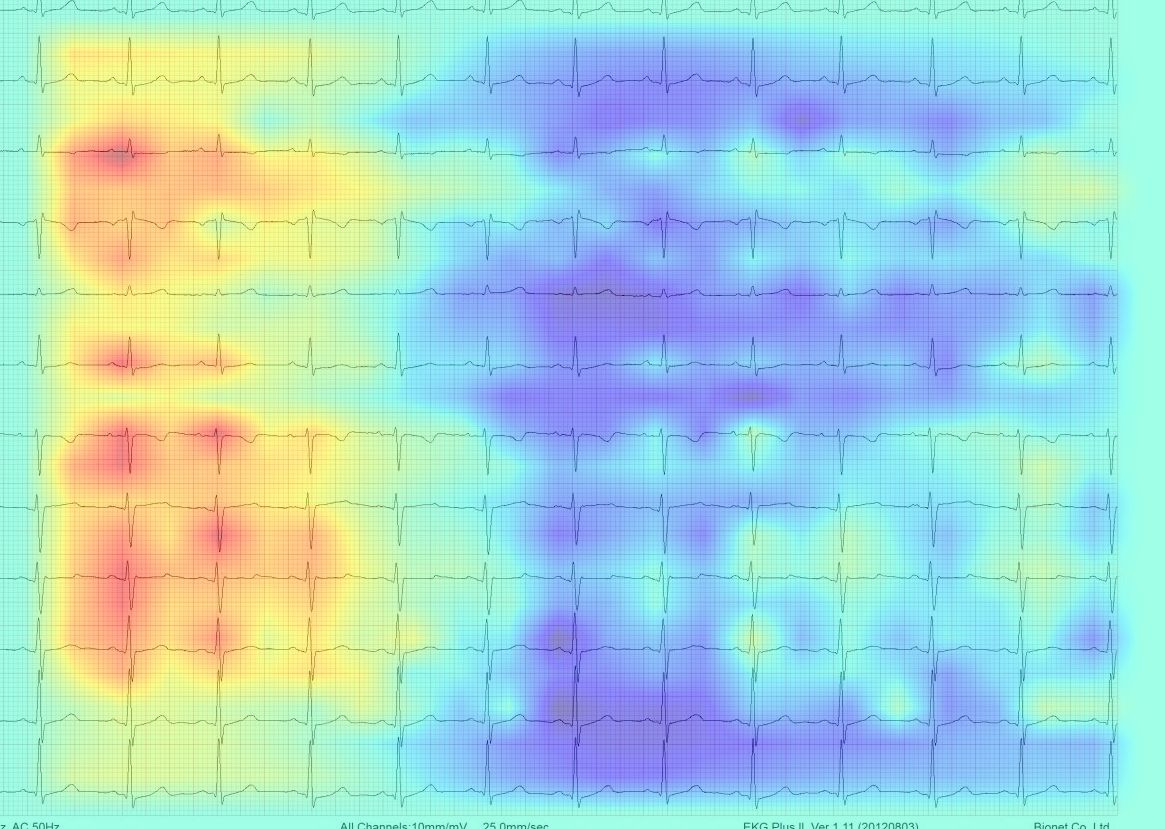

In [6]:
  model = CardioVLM().to(CFG.device)
  model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
  df = pd.read_csv(CFG.metadata_csv)
  explain_prediction(model, df.iloc[0], CFG.device)

In [8]:
"""
Report generation quality evaluation
=====================================
Up to now the decoder's report output has only been eyeballed on single
samples ("Findings: Normal Axis." vs ground truth "Findings: Normal Sinus
Rhythm; Normal Axis; Normal ECG.") — this runs it systematically over the
whole TEST set (touched once, same set used for the final classification
numbers) and reports three things text quality metrics alone can't:

  1. Standard text-overlap metrics (BLEU-1/2, ROUGE-L) — how close the
     generated text is to the ground truth report, word-for-word.
  2. Condition-mention recall/precision — did the generated TEXT actually
     name the right conditions, regardless of exact wording? (a report that
     says "Findings: Sinus Bradycardia present" vs ground truth "Findings:
     Sinus Bradycardia" scores low on BLEU but should score perfectly here)
  3. Cross-head consistency — does the decoder's generated text agree with
     the classification head's own predictions on the SAME input? If the
     two heads disagree often, that's a real problem: it means the model
     doesn't have one coherent internal understanding of the ECG, it has two
     separate outputs that happen to share an encoder.

Run this in a new cell AFTER the main training cell (reuses CFG, CardioVLM,
CONDITION_VOCAB, PairedECGDataset, tokenizer, etc. already in the notebook).
"""

import json
import re
from collections import Counter


def extract_conditions_from_text(text, condition_vocab):
    """Same word-boundary matching parse_diagnosis uses on OCR'd text (fixes
    the earlier 'MI' substring-inside-'Minimally' bug) — applied here to the
    model's own generated/ground-truth report text instead of OCR output."""
    text_lower = text.lower()
    found = set()
    for cond in condition_vocab:
        if re.search(r"\b" + re.escape(cond.lower()) + r"\b", text_lower):
            found.add(cond)
    return found


def _ngrams(tokens, n):
    return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))


def bleu_n(candidate, reference, n):
    """Simple single-reference BLEU-n with add-1 smoothing (add-1 avoids the
    0-if-any-n-gram-is-missing cliff that plain BLEU has on short clinical
    sentences, where a single wrong word would otherwise zero out the score)."""
    cand_tokens = candidate.lower().split()
    ref_tokens = reference.lower().split()
    if len(cand_tokens) < n:
        return 0.0
    cand_ngrams = _ngrams(cand_tokens, n)
    ref_ngrams = _ngrams(ref_tokens, n)
    overlap = sum(min(c, ref_ngrams[g]) for g, c in cand_ngrams.items())
    total = sum(cand_ngrams.values())
    precision = (overlap + 1) / (total + 1)
    bp = 1.0 if len(cand_tokens) >= len(ref_tokens) else \
        np.exp(1 - len(ref_tokens) / max(len(cand_tokens), 1))
    return bp * precision


def rouge_l(candidate, reference):
    """ROUGE-L: F-measure over the longest common subsequence of tokens —
    rewards preserving the right words in the right relative order even if
    phrasing differs, which matters more for clinical text than exact n-gram
    match."""
    cand_tokens = candidate.lower().split()
    ref_tokens = reference.lower().split()
    if not cand_tokens or not ref_tokens:
        return 0.0
    m, n = len(cand_tokens), len(ref_tokens)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if cand_tokens[i - 1] == ref_tokens[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    lcs = dp[m][n]
    if lcs == 0:
        return 0.0
    precision = lcs / m
    recall = lcs / n
    return 2 * precision * recall / (precision + recall)


def evaluate_report_quality(model, test_ds, device, condition_vocab, thresholds,
                              max_samples=None):
    model.eval()
    n = len(test_ds) if max_samples is None else min(max_samples, len(test_ds))

    bleu1_scores, bleu2_scores, rougeL_scores = [], [], []
    gen_vs_gt_tp = gen_vs_gt_fp = gen_vs_gt_fn = 0
    gen_vs_cls_agree = gen_vs_cls_total = 0
    examples = []

    with torch.no_grad():
        for i in range(n):
            sample = test_ds[i]
            ecg = sample["ecg_image"].unsqueeze(0).to(device)
            beat = sample["beat_image"].unsqueeze(0).to(device)
            numeric = sample["numeric"].unsqueeze(0).to(device)

            texts, _ = model.generate_report(ecg, beat, numeric)
            generated = texts[0]
            ground_truth = sample["report_text"]

            bleu1_scores.append(bleu_n(generated, ground_truth, 1))
            bleu2_scores.append(bleu_n(generated, ground_truth, 2))
            rougeL_scores.append(rouge_l(generated, ground_truth))

            gen_conds = extract_conditions_from_text(generated, condition_vocab)
            gt_conds = extract_conditions_from_text(ground_truth, condition_vocab)
            gen_vs_gt_tp += len(gen_conds & gt_conds)
            gen_vs_gt_fp += len(gen_conds - gt_conds)
            gen_vs_gt_fn += len(gt_conds - gen_conds)

            out = model(ecg, beat, numeric)
            probs = torch.sigmoid(out["logits"])[0].cpu().numpy()
            cls_conds = {name for name, p in zip(condition_vocab, probs) if p > thresholds[name]}
            gen_vs_cls_agree += len(gen_conds & cls_conds) + len((set(condition_vocab) - gen_conds) - cls_conds)
            gen_vs_cls_total += len(condition_vocab)

            if i < 10:
                examples.append((generated, ground_truth, gen_conds, gt_conds, cls_conds))

    precision = gen_vs_gt_tp / (gen_vs_gt_tp + gen_vs_gt_fp) if (gen_vs_gt_tp + gen_vs_gt_fp) > 0 else 0.0
    recall = gen_vs_gt_tp / (gen_vs_gt_tp + gen_vs_gt_fn) if (gen_vs_gt_tp + gen_vs_gt_fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    cross_head_agreement = gen_vs_cls_agree / gen_vs_cls_total if gen_vs_cls_total > 0 else 0.0

    print(f"\n=== Report generation quality (TEST set, n={n}) ===")
    print(f"BLEU-1:  {np.mean(bleu1_scores):.3f}")
    print(f"BLEU-2:  {np.mean(bleu2_scores):.3f}")
    print(f"ROUGE-L: {np.mean(rougeL_scores):.3f}")
    print(f"\nCondition-mention (generated text vs ground-truth text, word-boundary matched):")
    print(f"  precision={precision:.3f}  recall={recall:.3f}  F1={f1:.3f}")
    print(f"\nCross-head agreement (generated text's conditions vs classification "
          f"head's own predictions, same input, per-condition agreement rate):")
    print(f"  {cross_head_agreement:.3f}")
    if cross_head_agreement < 0.85:
        print("  -> Below 0.85: the decoder and classifier disagree often enough that "
              "they don't appear to share one coherent understanding of the ECG. Worth "
              "flagging as a limitation — the two output heads may be learning "
              "somewhat independent shortcuts rather than a unified representation.")

    print(f"\n=== {min(10, n)} example generations ===")
    for gen, gt, gen_c, gt_c, cls_c in examples:
        print(f"  Generated: {gen}")
        print(f"  Ground truth: {gt}")
        print(f"  Text-conditions: {sorted(gen_c)} | Ground-truth-conditions: {sorted(gt_c)} "
              f"| Classifier-conditions: {sorted(cls_c)}")
        print()

    return {
        "bleu1": float(np.mean(bleu1_scores)),
        "bleu2": float(np.mean(bleu2_scores)),
        "rougeL": float(np.mean(rougeL_scores)),
        "condition_precision": precision,
        "condition_recall": recall,
        "condition_f1": f1,
        "cross_head_agreement": cross_head_agreement,
    }


# ---------------------------------------------------------------------------
# Example usage (run in a new cell after the main training cell):
#
#   model = CardioVLM().to(CFG.device)
#   model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
#   with open(f"{CFG.out_dir}/label_config.json") as f:
#       label_config = json.load(f)
#   thresholds = label_config["thresholds"]
#
#   with open(f"{CFG.out_dir}/splits.json") as f:
#       splits = json.load(f)
#   df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})   # dtype forced —
#   # otherwise pandas silently infers patient_id as int64 on reload (it's an
#   # all-digit string column), which won't match the strings saved in
#   # splits.json and test_df comes back empty (n=0) with no error
#   test_df = df[df["patient_id"].isin(splits["test"])]
#   tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
#   test_ds = PairedECGDataset(test_df, tokenizer)
#
#   results = evaluate_report_quality(model, test_ds, CFG.device, CONDITION_VOCAB, thresholds)
#
# Uses the SAME test set as the final classification numbers (via splits.json)
# so this is a genuinely held-out check, not re-using train/val data.
# ---------------------------------------------------------------------------

In [9]:
model = CardioVLM().to(CFG.device)

model.load_state_dict(
    torch.load(
        f"{CFG.out_dir}/cardiovlm_best.pt",
        map_location=CFG.device
    )
)

# Load saved thresholds
with open(f"{CFG.out_dir}/label_config.json", "r") as f:
    label_config = json.load(f)

thresholds = label_config["thresholds"]

# Load the original train/validation/test split
with open(f"{CFG.out_dir}/splits.json", "r") as f:
    splits = json.load(f)

# Load the training-only numeric preprocessing statistics
with open(
    f"{CFG.out_dir}/numeric_preprocessing.json",
    "r"
) as f:
    preprocessing = json.load(f)

train_medians = pd.Series(
    preprocessing["train_medians"],
    dtype=np.float32
)

numeric_means = pd.Series(
    preprocessing["numeric_means"],
    index=NUMERIC_COLS,
    dtype=np.float32
)

numeric_stds = (
    pd.Series(
        preprocessing["numeric_stds"],
        index=NUMERIC_COLS,
        dtype=np.float32
    )
    .replace(0, 1)
    .fillna(1)
)

# Keep patient IDs as strings
df = pd.read_csv(
    CFG.metadata_csv,
    dtype={"patient_id": str}
)

test_df = df[
    df["patient_id"].isin(splits["test"])
].copy()

if len(test_df) == 0:
    raise ValueError(
        "Test set is empty. patient_id values do not match splits.json."
    )

# Apply the training-set medians to test data
impute_cols = [
    "hr", "pr", "qrs", "qt", "qtc",
    "p_axis", "qrs_axis", "t_axis"
]

test_df[impute_cols] = (
    test_df[impute_cols]
    .fillna(train_medians)
)

test_df["axes_missing"] = (
    test_df["axes_missing"]
    .fillna(1.0)
    .astype(np.float32)
)

tokenizer = AutoTokenizer.from_pretrained(
    CFG.decoder_name
)

# Pass the two previously missing arguments
test_ds = PairedECGDataset(
    test_df,
    tokenizer,
    numeric_means,
    numeric_stds
)

print("Test samples:", len(test_ds))

results = evaluate_report_quality(
    model,
    test_ds,
    CFG.device,
    CONDITION_VOCAB,
    thresholds
)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Test samples: 375

=== Report generation quality (TEST set, n=375) ===
BLEU-1:  0.639
BLEU-2:  0.610
ROUGE-L: 0.732

Condition-mention (generated text vs ground-truth text, word-boundary matched):
  precision=0.893  recall=0.599  F1=0.717

Cross-head agreement (generated text's conditions vs classification head's own predictions, same input, per-condition agreement rate):
  0.925

=== 10 example generations ===
  Generated: Findings: Normal Sinus Rhythm; Normal Axis.
  Ground truth: Findings: Normal Sinus Rhythm; Normal Axis; Normal ECG.
  Text-conditions: ['Normal Axis', 'Normal Sinus Rhythm'] | Ground-truth-conditions: ['Normal Axis', 'Normal ECG', 'Normal Sinus Rhythm'] | Classifier-conditions: ['Normal Axis', 'Normal ECG', 'Normal Sinus Rhythm']

  Generated: Findings: Normal Axis; Sinus Bradycardia.
  Ground truth: Findings: Normal Axis; Sinus Bradycardia.
  Text-conditions: ['Normal Axis', 'Sinus Bradycardia'] | Ground-truth-conditions: ['Normal Axis', 'Sinus Bradycardia'] | Clas

In [11]:
"""
Multi-seed evaluation
======================
Test macro_f1 has swung 0.271-0.438 across runs on the IDENTICAL train/val/
test split — meaning only the split was ever seeded, not model init or batch
order. A single run's number isn't trustworthy enough to report in a paper.

This holds the split fixed (reconstructed from splits.json, so it's the exact
same train/val/test patients every time) and varies ONLY the model init +
dataloader shuffling seed across several full training runs, so the resulting
spread isolates training-randomness instability specifically — not a mix of
"the split changed" and "the model changed", which is what was actually
varying across your last several runs.

Deliberately skips the expensive k-fold threshold calibration per seed —
evaluates all seeds at a fixed 0.5 threshold instead. Retuning thresholds per
seed would confound two different questions ("is the model stable" vs "is the
calibration stable"); this isolates the first one, which is what you asked.

Run this in a new cell AFTER the main training cell (reuses CFG, CardioVLM,
PairedECGDataset, CONDITION_VOCAB, train_one_epoch, evaluate, macro_f1_score,
etc. already in the notebook).

COST WARNING: this trains the full model from scratch once per seed (up to
CFG.epochs each, same as your main run). 3 seeds ~= 3x the time of one full
training run. Start with 3, not 5, unless you have time to spare.
"""

import copy
import random


def run_multi_seed_evaluation(train_df, val_df, test_df, tokenizer, device,
                                 numeric_means, numeric_stds,
                                 seeds=(0, 1, 2), epochs=None,
                                 min_decoder_epochs=None, patience=4):
    # numeric_means/numeric_stds are now required (not optional) because
    # PairedECGDataset itself now requires them -- they must be TRAIN-ONLY
    # statistics (see the numeric-normalization leakage fix); load them from
    # {CFG.out_dir}/numeric_preprocessing.json rather than recomputing here,
    # so this uses the exact same stats the deployed model was trained with.
    # train_df/val_df/test_df must also already have their numeric columns
    # median-filled (PairedECGDataset no longer imputes internally) -- see
    # the usage example at the bottom of this file.
    epochs = epochs or CFG.epochs
    min_decoder_epochs = min_decoder_epochs or CFG.min_decoder_epochs

    train_ds = PairedECGDataset(train_df, tokenizer, numeric_means, numeric_stds)
    val_ds = PairedECGDataset(val_df, tokenizer, numeric_means, numeric_stds)
    test_ds = PairedECGDataset(test_df, tokenizer, numeric_means, numeric_stds)

    label_cols = [f"label_{c.replace(' ', '_')}" for c in CONDITION_VOCAB]
    pos_counts = train_df[label_cols].sum().values
    neg_counts = len(train_df) - pos_counts
    pos_weight = np.clip(neg_counts / np.maximum(pos_counts, 1), 1.0, 8.0)
    pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)

    results = []
    for seed in seeds:
        print(f"\n{'=' * 70}\n=== Seed {seed} ===\n{'=' * 70}")
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(seed)
        random.seed(seed)

        train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)
        test_loader = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)

        model = CardioVLM().to(device)
        decoder_params = list(model.decoder.parameters())
        other_params = [p for n, p in model.named_parameters() if not n.startswith("decoder.")]
        optimizer = torch.optim.AdamW([
            {"params": other_params, "lr": CFG.lr},
            {"params": decoder_params, "lr": CFG.effective_decoder_lr},
        ])

        best_f1 = -1
        best_state = None
        epochs_since_improvement = 0

        for epoch in range(epochs):
            loss, cls_loss, report_loss = train_one_epoch(
                model, train_loader, optimizer, device, pos_weight=pos_weight)
            val_macro_f1 = macro_f1_score(model, val_loader, device, CONDITION_VOCAB)
            print(f"  seed {seed} epoch {epoch + 1}/{epochs} | loss={loss:.4f} "
                  f"report={report_loss:.4f} macro_f1={val_macro_f1:.3f}")

            if epoch + 1 < min_decoder_epochs:
                # same decoder-warmup floor as the main training loop — a
                # checkpoint frozen before this would risk the same
                # undertrained-decoder problem that showed up on the larger
                # dataset
                continue

            if val_macro_f1 > best_f1:
                best_f1 = val_macro_f1
                best_state = copy.deepcopy(model.state_dict())
                epochs_since_improvement = 0
            else:
                epochs_since_improvement += 1
                if epochs_since_improvement >= patience:
                    print(f"  seed {seed}: no improvement for {patience} epochs, "
                          f"stopping early at epoch {epoch + 1}.")
                    break

        model.load_state_dict(best_state)
        test_exact_match, test_per_label_acc = evaluate(model, test_loader, device)
        test_macro_f1 = macro_f1_score(model, test_loader, device, CONDITION_VOCAB)
        print(f"  seed {seed} FINAL (best val macro_f1={best_f1:.3f}) -> "
              f"test exact_match={test_exact_match:.3f} per_label_acc={test_per_label_acc:.3f} "
              f"test_macro_f1={test_macro_f1:.3f}")

        # Persist this seed's checkpoint -- previously discarded after scoring,
        # which meant the 3 independently-trained models couldn't be reused
        # for anything (like ensembling) afterward.
        seed_ckpt_path = os.path.join(CFG.out_dir, f"seed_{seed}_best.pt")
        torch.save(best_state, seed_ckpt_path)
        print(f"  seed {seed}: checkpoint saved to {seed_ckpt_path}")

        results.append({
            "seed": seed,
            "val_macro_f1": best_f1,
            "test_exact_match": test_exact_match,
            "test_per_label_acc": test_per_label_acc,
            "test_macro_f1": test_macro_f1,
            "checkpoint_path": seed_ckpt_path,
        })

        del model, best_state, optimizer
        torch.cuda.empty_cache()

    test_f1s = np.array([r["test_macro_f1"] for r in results])
    print(f"\n{'=' * 70}")
    print(f"=== Multi-seed summary ({len(seeds)} seeds, SAME train/val/test split, "
          f"only model init + batch order varied) ===")
    print(f"{'=' * 70}")
    for r in results:
        print(f"  seed {r['seed']}: test_macro_f1={r['test_macro_f1']:.3f}  "
              f"test_exact_match={r['test_exact_match']:.3f}  "
              f"test_per_label_acc={r['test_per_label_acc']:.3f}")

    std = test_f1s.std(ddof=1) if len(test_f1s) > 1 else 0.0
    print(f"\nTest macro_f1: mean={test_f1s.mean():.3f}  std={std:.3f}  "
          f"min={test_f1s.min():.3f}  max={test_f1s.max():.3f}")
    print(f"\nReport this as mean +/- std in the paper, not any single run's number — "
          f"the spread above is the honest measure of how reliable this model/dataset "
          f"combination actually is, not noise to average away.")

    return results


# ---------------------------------------------------------------------------
# Example usage (run in a new cell after the main training cell):
#
#   with open(f"{CFG.out_dir}/splits.json") as f:
#       splits = json.load(f)
#   with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
#       preprocessing = json.load(f)
#   train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
#   numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
#   numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)
#
#   df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
#   for col in train_medians.index:
#       df[col] = df[col].fillna(train_medians[col])
#   df["axes_missing"] = df["axes_missing"].fillna(1.0)
#
#   train_df = df[df["patient_id"].isin(splits["train"])]
#   val_df = df[df["patient_id"].isin(splits["val"])]
#   test_df = df[df["patient_id"].isin(splits["test"])]
#   tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
#
#   results = run_multi_seed_evaluation(train_df, val_df, test_df, tokenizer,
#                                          CFG.device, numeric_means, numeric_stds,
#                                          seeds=(0, 1, 2))
#
# COST WARNING: trains from scratch once per seed (up to CFG.epochs each).
# 3 seeds ~= 3x the time of one full training run — start with 3, not 5,
# unless you have time to spare.
# ---------------------------------------------------------------------------

In [12]:
with open(f"{CFG.out_dir}/splits.json") as f:
    splits = json.load(f)
with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
    preprocessing = json.load(f)
train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)

df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
for col in train_medians.index:
    df[col] = df[col].fillna(train_medians[col])
df["axes_missing"] = df["axes_missing"].fillna(1.0)

train_df = df[df["patient_id"].isin(splits["train"])]
val_df = df[df["patient_id"].isin(splits["val"])]
test_df = df[df["patient_id"].isin(splits["test"])]
tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)

results = run_multi_seed_evaluation(train_df, val_df, test_df, tokenizer, CFG.device,
                                       numeric_means, numeric_stds, seeds=(0, 1, 2))


=== Seed 0 ===


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  seed 0 epoch 1/15 | loss=1.4102 report=5.3407 macro_f1=0.201
  seed 0 epoch 2/15 | loss=0.6016 report=0.7969 macro_f1=0.240
  seed 0 epoch 3/15 | loss=0.4790 report=0.3597 macro_f1=0.312
  seed 0 epoch 4/15 | loss=0.4218 report=0.2422 macro_f1=0.306
  seed 0 epoch 5/15 | loss=0.3916 report=0.1963 macro_f1=0.324
  seed 0 epoch 6/15 | loss=0.3590 report=0.1644 macro_f1=0.339
  seed 0 epoch 7/15 | loss=0.3380 report=0.1433 macro_f1=0.386
  seed 0 epoch 8/15 | loss=0.3191 report=0.1294 macro_f1=0.325
  seed 0 epoch 9/15 | loss=0.2891 report=0.1212 macro_f1=0.272
  seed 0 epoch 10/15 | loss=0.2671 report=0.1120 macro_f1=0.346
  seed 0 epoch 11/15 | loss=0.2469 report=0.1069 macro_f1=0.343
  seed 0 epoch 12/15 | loss=0.2330 report=0.0989 macro_f1=0.393
  seed 0 epoch 13/15 | loss=0.2060 report=0.0952 macro_f1=0.410
  seed 0 epoch 14/15 | loss=0.1856 report=0.0866 macro_f1=0.407
  seed 0 epoch 15/15 | loss=0.1806 report=0.0860 macro_f1=0.452
  seed 0 FINAL (best val macro_f1=0.452) -> test 

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  seed 1 epoch 1/15 | loss=1.3867 report=5.3217 macro_f1=0.200
  seed 1 epoch 2/15 | loss=0.6151 report=0.8351 macro_f1=0.271
  seed 1 epoch 3/15 | loss=0.4905 report=0.3647 macro_f1=0.327
  seed 1 epoch 4/15 | loss=0.4285 report=0.2407 macro_f1=0.327
  seed 1 epoch 5/15 | loss=0.3928 report=0.1859 macro_f1=0.357
  seed 1 epoch 6/15 | loss=0.3760 report=0.1633 macro_f1=0.356
  seed 1 epoch 7/15 | loss=0.3527 report=0.1468 macro_f1=0.314
  seed 1 epoch 8/15 | loss=0.3273 report=0.1331 macro_f1=0.412
  seed 1 epoch 9/15 | loss=0.2957 report=0.1168 macro_f1=0.367
  seed 1 epoch 10/15 | loss=0.2760 report=0.1139 macro_f1=0.361
  seed 1 epoch 11/15 | loss=0.2664 report=0.1050 macro_f1=0.301
  seed 1 epoch 12/15 | loss=0.2483 report=0.1019 macro_f1=0.300
  seed 1: no improvement for 4 epochs, stopping early at epoch 12.
  seed 1 FINAL (best val macro_f1=0.412) -> test exact_match=0.419 per_label_acc=0.939 test_macro_f1=0.441
  seed 1: checkpoint saved to /kaggle/working/cardiovlm_ckpt_combo2

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  seed 2 epoch 1/15 | loss=1.4383 report=5.6429 macro_f1=0.207
  seed 2 epoch 2/15 | loss=0.5907 report=0.8260 macro_f1=0.282
  seed 2 epoch 3/15 | loss=0.4789 report=0.3462 macro_f1=0.273
  seed 2 epoch 4/15 | loss=0.4280 report=0.2363 macro_f1=0.302
  seed 2 epoch 5/15 | loss=0.3944 report=0.1792 macro_f1=0.365
  seed 2 epoch 6/15 | loss=0.3747 report=0.1588 macro_f1=0.355
  seed 2 epoch 7/15 | loss=0.3453 report=0.1403 macro_f1=0.298
  seed 2 epoch 8/15 | loss=0.3256 report=0.1298 macro_f1=0.407
  seed 2 epoch 9/15 | loss=0.2970 report=0.1182 macro_f1=0.380
  seed 2 epoch 10/15 | loss=0.2719 report=0.1129 macro_f1=0.353
  seed 2 epoch 11/15 | loss=0.2525 report=0.1023 macro_f1=0.375
  seed 2 epoch 12/15 | loss=0.2355 report=0.0953 macro_f1=0.362
  seed 2: no improvement for 4 epochs, stopping early at epoch 12.
  seed 2 FINAL (best val macro_f1=0.407) -> test exact_match=0.557 per_label_acc=0.948 test_macro_f1=0.484
  seed 2: checkpoint saved to /kaggle/working/cardiovlm_ckpt_combo2

In [13]:
"""
Ensemble + tiered-confidence report generation
=================================================
Two changes over the single-model report generator, aimed specifically at
reducing missed findings (e.g. the Low Voltage miss on Patient 4, the LVH
miss on Patient 8 in the last batch of 10):

  1. ENSEMBLE ACROSS SEEDS. This project's own multi-seed check showed a
     single checkpoint's predictions are noisier than they look -- test
     macro_f1 swung 0.271-0.484 across otherwise-identical runs. Averaging
     sigmoid probabilities across multiple independently-trained models
     (the seed_N_best.pt checkpoints, now saved by the updated multi-seed
     script) gives steadier, usually more accurate per-patient predictions
     than any single model -- this is the standard reason ensembling helps,
     and directly targets exactly this kind of single-model miss.

  2. A SECOND, LOWER "POSSIBLE FINDING" TIER. The formal classification
     threshold was tuned to optimize F1 for the classification metric, not
     for what a report reader wants. For a report, a missed real finding is
     worse than a flagged uncertain one. Anything scoring between a lower
     "possible" cutoff and the formal threshold is now shown in a separate,
     clearly-labeled section instead of being silently invisible.

Run this in a new cell after the main training cell AND after the (updated)
multi-seed evaluation cell has run at least once with checkpoint saving
enabled (produces {CFG.out_dir}/seed_0_best.pt, seed_1_best.pt, ...).
"""

import glob
import copy

# Self-contained: previously this reused CONDITION_PHRASING/NORMAL_CONDITIONS/
# LOW_SUPPORT_CAVEAT from a separate human_readable_report cell, which broke
# with NameError when that cell wasn't run first in the same notebook. Now
# defined directly here so this file works standalone.
CONDITION_PHRASING = {
    "Normal Sinus Rhythm": "normal sinus rhythm",
    "Normal Axis": "a normal frontal-plane axis",
    "Normal ECG": "an otherwise normal ECG",
    "ICRBBB": "an incomplete right bundle branch block (ICRBBB)",
    "Atrial Fibrillation": "atrial fibrillation",
    "Sinus Bradycardia": "sinus bradycardia (a slower-than-normal heart rate)",
    "Sinus Tachycardia": "sinus tachycardia (a faster-than-normal heart rate)",
    "Left Axis Deviation": "left axis deviation",
    "Right Axis Deviation": "right axis deviation",
    "Inferior MI": "findings suggestive of an inferior myocardial infarction",
    "Anteroseptal MI": "findings suggestive of an anteroseptal myocardial infarction",
    "MI": "findings suggestive of a myocardial infarction",
    "ST abnormality": "an ST-segment abnormality",
    "Markedly Abnormal ECG": "a markedly abnormal overall ECG pattern",
    "LVH": "left ventricular hypertrophy (LVH)",
    "RVH": "right ventricular hypertrophy (RVH)",
    "PVC": "premature ventricular contractions (PVCs)",
    "Low Voltage": "low QRS voltage",
    "PAC": "premature atrial contractions (PACs)",
}
NORMAL_CONDITIONS = {"Normal Sinus Rhythm", "Normal Axis", "Normal ECG"}
LOW_SUPPORT_CAVEAT = "this is a rare finding in the training data and the model's confidence for it should be treated cautiously"


def load_ensemble_models(device, ckpt_glob=None):
    """Loads every seed_*_best.pt checkpoint found, plus the main
    cardiovlm_best.pt if present, as a list of ready-to-eval models."""
    ckpt_glob = ckpt_glob or os.path.join(CFG.out_dir, "seed_*_best.pt")
    paths = sorted(glob.glob(ckpt_glob))
    main_ckpt = os.path.join(CFG.out_dir, "cardiovlm_best.pt")
    if os.path.exists(main_ckpt) and main_ckpt not in paths:
        paths.append(main_ckpt)
    if not paths:
        raise FileNotFoundError(
            f"No checkpoints found matching {ckpt_glob} (and no {main_ckpt}). "
            "Run the multi-seed evaluation cell first -- it now saves each "
            "seed's checkpoint instead of discarding it.")
    models = []
    for p in paths:
        m = CardioVLM().to(device)
        m.load_state_dict(torch.load(p, map_location=device))
        m.eval()
        models.append(m)
    print(f"Loaded {len(models)} model(s) for ensembling: {[os.path.basename(p) for p in paths]}")
    return models


def ensemble_predict_probs(models, ecg_tensor, beat_tensor, numeric_tensor):
    """Averages sigmoid probabilities across all models -- averaging
    probabilities (not logits) is the more standard and robust choice for
    an ensemble of classifiers with potentially different calibration."""
    all_probs = []
    with torch.no_grad():
        for m in models:
            out = m(ecg_tensor, beat_tensor, numeric_tensor)
            all_probs.append(torch.sigmoid(out["logits"]))
    return torch.stack(all_probs, dim=0).mean(dim=0)[0].cpu().numpy()


def render_tiered_report(high_confidence, possible, low_support_conditions=None):
    """Like render_human_readable_report, but with an added 'possible
    finding' section for anything between the possible-cutoff and the
    formal threshold -- surfaced instead of silently hidden, since a report
    reader is better served by an uncertain mention than a silent miss."""
    low_support_conditions = low_support_conditions or {}
    names = [name for name, _ in high_confidence]
    normal_found = [n for n in names if n in NORMAL_CONDITIONS]
    abnormal_found = [(n, c) for n, c in high_confidence if n not in NORMAL_CONDITIONS]

    lines = []
    if normal_found and not abnormal_found:
        phrases = [CONDITION_PHRASING[n] for n in normal_found]
        joined = phrases[0] if len(phrases) == 1 else \
            (f"{phrases[0]} and {phrases[1]}" if len(phrases) == 2 else
             ", ".join(phrases[:-1]) + f", and {phrases[-1]}")
        lines.append(f"This ECG shows {joined}. No other high-confidence abnormalities were detected.")
        lines.append("\nOverall impression: Normal ECG.")
    else:
        if normal_found:
            phrases = [CONDITION_PHRASING[n] for n in normal_found]
            joined = phrases[0] if len(phrases) == 1 else \
                ", ".join(phrases[:-1]) + f", and {phrases[-1]}"
            lines.append(f"This ECG shows {joined}.")
        else:
            lines.append("This ECG does not show a clearly normal baseline rhythm/axis pattern.")

        lines.append("\nFindings:")
        for name, conf in abnormal_found:
            phrase = CONDITION_PHRASING.get(name, name)
            caveat = f" Note: {LOW_SUPPORT_CAVEAT}." if name in low_support_conditions else ""
            lines.append(f"  - {phrase[0].upper() + phrase[1:]} (model confidence: {conf:.0%}).{caveat}")
        lines.append("\nOverall impression: Abnormal ECG — see findings above.")

    if possible:
        lines.append(
            "\nPossible additional findings (below the model's standard confidence "
            "threshold — mentioned for completeness, not confirmed):"
        )
        for name, conf in possible:
            phrase = CONDITION_PHRASING.get(name, name)
            lines.append(f"  - Possible {phrase} (model confidence: {conf:.0%}).")

    lines.append(
        "\nThis report was generated by a research model (CardioVLM, ensemble of "
        f"multiple models) and is not a substitute for physician interpretation. "
        "Clinical correlation is recommended."
    )
    return "\n".join(lines)


def render_ensemble_report_for_patient(models, row, device, thresholds, condition_vocab,
                                          numeric_means, numeric_stds, train_medians,
                                          low_support_conditions=None, possible_margin=0.20,
                                          tokenizer=None, _print=True):
    """possible_margin: how far below each condition's formal threshold counts
    as a 'possible finding' (default 0.20 -- e.g. a threshold of 0.55 means
    anything scoring 0.35-0.55 shows up as 'possible' instead of invisible)."""
    transform = T.Compose([
        ResizeWithPadding(CFG.img_size),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    rhythm_grid = crop_rhythm_regions(row["rhythm_path"])["grid"]
    beat_grid = crop_beat_regions(row["beat_path"])["grid"]
    ecg_tensor = transform(rhythm_grid).unsqueeze(0).to(device)
    beat_tensor = transform(beat_grid).unsqueeze(0).to(device)

    numeric_values = pd.Series(
        {col: row[col] if col in row.index else np.nan for col in NUMERIC_COLS},
        dtype=np.float32)
    for col in train_medians.index:
        if pd.isna(numeric_values[col]):
            numeric_values[col] = train_medians[col]
    if pd.isna(numeric_values["axes_missing"]):
        numeric_values["axes_missing"] = 1.0
    numeric_norm = (numeric_values.values - numeric_means.values) / numeric_stds.values
    numeric_tensor = torch.tensor(numeric_norm, dtype=torch.float32).unsqueeze(0).to(device)

    probs = ensemble_predict_probs(models, ecg_tensor, beat_tensor, numeric_tensor)

    high_confidence, possible = [], []
    for name, p in zip(condition_vocab, probs):
        t = thresholds[name]
        if p > t:
            high_confidence.append((name, float(p)))
        elif p > max(t - possible_margin, 0.0):
            possible.append((name, float(p)))

    report = render_tiered_report(high_confidence, possible, low_support_conditions)

    decoder_text = None
    if tokenizer is not None:
        # decoder text from the first ensemble member only (generation isn't
        # meaningfully ensemble-able the way classification logits are)
        texts, _ = models[0].generate_report(ecg_tensor, beat_tensor, numeric_tensor)
        decoder_text = texts[0]

    if _print:
        print("=" * 70)
        print(f"ENSEMBLE REPORT ({len(models)} models):")
        print("=" * 70)
        print(report)
        if decoder_text is not None:
            print("\n" + "-" * 70)
            print("Decoder's own generated text (secondary/informal reference):")
            print("-" * 70)
            print(decoder_text)
    return report, high_confidence, possible, decoder_text


# ---------------------------------------------------------------------------
# Example usage (run in a new cell after the main training cell, and after
# the multi-seed evaluation cell has produced seed_0_best.pt etc.):
#
#   models = load_ensemble_models(CFG.device)
#
#   with open(f"{CFG.out_dir}/label_config.json") as f:
#       label_config = json.load(f)
#   thresholds = label_config["thresholds"]
#   low_support = label_config.get("low_support_conditions", {})
#
#   with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
#       preprocessing = json.load(f)
#   train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
#   numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
#   numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)
#
#   with open(f"{CFG.out_dir}/splits.json") as f:
#       splits = json.load(f)
#   df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
#   test_df = df[df["patient_id"].isin(splits["test"])]
#   tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
#
#   row = test_df.iloc[3]   # e.g. the Low Voltage patient that got missed
#   _ = render_ensemble_report_for_patient(models, row, CFG.device, thresholds,
#                                             CONDITION_VOCAB, numeric_means, numeric_stds,
#                                             train_medians, low_support_conditions=low_support,
#                                             tokenizer=tokenizer)
# ---------------------------------------------------------------------------

In [15]:
  models = load_ensemble_models(CFG.device)

  with open(f"{CFG.out_dir}/label_config.json") as f:
      label_config = json.load(f)
  thresholds = label_config["thresholds"]
  low_support = label_config.get("low_support_conditions", {})

  with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
      preprocessing = json.load(f)
  train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
  numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
  numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)

  with open(f"{CFG.out_dir}/splits.json") as f:
      splits = json.load(f)
  df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
  test_df = df[df["patient_id"].isin(splits["test"])]
  tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)

  row = test_df.iloc[3]   # e.g. the Low Voltage patient that got missed
  _ = render_ensemble_report_for_patient(models, row, CFG.device, thresholds,
                                            CONDITION_VOCAB, numeric_means, numeric_stds,
                                            train_medians, low_support_conditions=low_support,
                                            tokenizer=tokenizer)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loaded 4 model(s) for ensembling: ['seed_0_best.pt', 'seed_1_best.pt', 'seed_2_best.pt', 'cardiovlm_best.pt']
ENSEMBLE REPORT (4 models):
This ECG shows normal sinus rhythm, a normal frontal-plane axis, and an otherwise normal ECG. No other high-confidence abnormalities were detected.

Overall impression: Normal ECG.

Possible additional findings (below the model's standard confidence threshold — mentioned for completeness, not confirmed):
  - Possible an incomplete right bundle branch block (ICRBBB) (model confidence: 49%).
  - Possible right axis deviation (model confidence: 1%).
  - Possible a markedly abnormal overall ECG pattern (model confidence: 9%).
  - Possible premature atrial contractions (PACs) (model confidence: 9%).

This report was generated by a research model (CardioVLM, ensemble of multiple models) and is not a substitute for physician interpretation. Clinical correlation is recommended.

----------------------------------------------------------------------
Decoder's

In [16]:
"""
Ensemble evaluation on the full test set
==========================================
Up to now the ensemble report generator has only been checked on one
patient. This runs it over the WHOLE test set and reports:

  1. The ensemble's actual macro_f1/exact_match/per_label_acc, computed the
     same way as the single-model FINAL TEST SET numbers, so it's directly
     comparable -- confirms (or not) that averaging the 3 saved seed
     checkpoints actually beats any single one, rather than assuming it does.

  2. How often the "possible finding" tier fires on patients who are
     GENUINELY, FULLY NORMAL (ground truth = only Normal Sinus Rhythm/Axis/
     ECG). If this tier is firing 3-5 items per normal patient, the 0.20
     margin is too generous and turns every report into boilerplate noise --
     this number tells you directly whether that's actually happening across
     the dataset, not just in the one example already seen.

Run this in a new cell after the ensemble_report.py cell (reuses
load_ensemble_models, ensemble_predict_probs, etc. already defined there).
"""


def evaluate_ensemble_on_test_set(models, test_df, tokenizer, device, thresholds,
                                     condition_vocab, numeric_means, numeric_stds,
                                     train_medians, possible_margin=0.20):
    test_ds = PairedECGDataset(test_df, tokenizer, numeric_means, numeric_stds)
    test_loader = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)

    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            ecg = batch["ecg_image"].to(device)
            beat = batch["beat_image"].to(device)
            numeric = batch["numeric"].to(device)
            labels = batch["labels"].to(device)

            batch_probs = torch.stack(
                [torch.sigmoid(m(ecg, beat, numeric)["logits"]) for m in models], dim=0
            ).mean(dim=0)
            all_probs.append(batch_probs.cpu())
            all_labels.append(labels.cpu())

    probs = torch.cat(all_probs).numpy()
    labels = torch.cat(all_labels).numpy()
    threshold_arr = np.array([thresholds[name] for name in condition_vocab])
    preds = (probs > threshold_arr[None, :]).astype(np.float32)

    # --- aggregate metrics, same definitions as the single-model FINAL TEST SET block ---
    exact_match = float((preds == labels).all(axis=1).mean())
    per_label_acc = float((preds == labels).mean())

    f1s = []
    print(f"\n{'Condition':<28}{'Support':>8}{'Precision':>11}{'Recall':>9}{'F1':>7}")
    print("-" * 63)
    rows = []
    for i, name in enumerate(condition_vocab):
        tp = ((preds[:, i] == 1) & (labels[:, i] == 1)).sum()
        fp = ((preds[:, i] == 1) & (labels[:, i] == 0)).sum()
        fn = ((preds[:, i] == 0) & (labels[:, i] == 1)).sum()
        support = int(labels[:, i].sum())
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        f1s.append(f1)
        rows.append((name, support, precision, recall, f1))
    rows.sort(key=lambda r: r[1])
    for name, support, precision, recall, f1 in rows:
        print(f"{name:<28}{support:>8}{precision:>11.3f}{recall:>9.3f}{f1:>7.3f}")
    macro_f1 = float(np.mean(f1s))

    print(f"\nEnsemble ({len(models)} models) test set: "
          f"exact_match={exact_match:.3f} per_label_acc={per_label_acc:.3f} macro_f1={macro_f1:.3f}")

    # --- possible-tier firing rate on genuinely normal patients ---
    normal_cols = [condition_vocab.index(n) for n in
                   ["Normal Sinus Rhythm", "Normal Axis", "Normal ECG"]]
    other_cols = [i for i in range(len(condition_vocab)) if i not in normal_cols]
    fully_normal_mask = (labels[:, other_cols].sum(axis=1) == 0) & (labels[:, normal_cols].sum(axis=1) > 0)
    n_normal = int(fully_normal_mask.sum())

    possible_counts = []
    for row_idx in np.where(fully_normal_mask)[0]:
        row_probs = probs[row_idx]
        n_possible = 0
        for i, name in enumerate(condition_vocab):
            t = thresholds[name]
            if row_probs[i] <= t and row_probs[i] > max(t - possible_margin, 0.0):
                n_possible += 1
        possible_counts.append(n_possible)

    if n_normal > 0:
        possible_counts = np.array(possible_counts)
        print(f"\n=== 'Possible finding' tier firing rate on {n_normal} genuinely normal patients "
              f"(margin={possible_margin}) ===")
        print(f"  mean possible-tier items per normal patient: {possible_counts.mean():.2f}")
        print(f"  median: {np.median(possible_counts):.0f}   "
              f"% with 0 possible items: {(possible_counts == 0).mean():.1%}   "
              f"% with 3+: {(possible_counts >= 3).mean():.1%}")
        if possible_counts.mean() > 1.5:
            print("  -> Firing on average more than ~1-2 items per normal patient. This margin is "
                  "likely too generous and will make most normal-patient reports look cluttered with "
                  "low-value noise rather than clean 'Normal ECG' summaries. Consider narrowing "
                  "possible_margin (e.g. 0.10-0.15) or requiring a higher absolute floor.")
        else:
            print("  -> Firing rate looks reasonable -- most normal patients aren't accumulating a "
                  "long list of low-value 'possible' mentions.")

    return {
        "exact_match": exact_match,
        "per_label_acc": per_label_acc,
        "macro_f1": macro_f1,
        "possible_counts_on_normal": possible_counts.tolist() if n_normal > 0 else [],
    }


# ---------------------------------------------------------------------------
# Example usage (run in a new cell after the ensemble_report.py cell):
#
#   models = load_ensemble_models(CFG.device)
#
#   with open(f"{CFG.out_dir}/label_config.json") as f:
#       label_config = json.load(f)
#   thresholds = label_config["thresholds"]
#
#   with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
#       preprocessing = json.load(f)
#   train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
#   numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
#   numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)
#
#   with open(f"{CFG.out_dir}/splits.json") as f:
#       splits = json.load(f)
#   df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
#   for col in train_medians.index:
#       df[col] = df[col].fillna(train_medians[col])
#   df["axes_missing"] = df["axes_missing"].fillna(1.0)
#   test_df = df[df["patient_id"].isin(splits["test"])]
#   tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
#
#   results = evaluate_ensemble_on_test_set(models, test_df, tokenizer, CFG.device, thresholds,
#                                              CONDITION_VOCAB, numeric_means, numeric_stds, train_medians)
# ---------------------------------------------------------------------------

In [17]:
models = load_ensemble_models(CFG.device)

with open(f"{CFG.out_dir}/label_config.json") as f:
    label_config = json.load(f)
thresholds = label_config["thresholds"]

with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
    preprocessing = json.load(f)
train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)

with open(f"{CFG.out_dir}/splits.json") as f:
    splits = json.load(f)
df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
for col in train_medians.index:
    df[col] = df[col].fillna(train_medians[col])
df["axes_missing"] = df["axes_missing"].fillna(1.0)
test_df = df[df["patient_id"].isin(splits["test"])]
tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)

results = evaluate_ensemble_on_test_set(models, test_df, tokenizer, CFG.device, thresholds,
                                           CONDITION_VOCAB, numeric_means, numeric_stds, train_medians)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loaded 4 model(s) for ensembling: ['seed_0_best.pt', 'seed_1_best.pt', 'seed_2_best.pt', 'cardiovlm_best.pt']

Condition                    Support  Precision   Recall     F1
---------------------------------------------------------------
Atrial Fibrillation                2      0.500    0.500  0.500
Right Axis Deviation               2      0.333    1.000  0.500
RVH                                2      1.000    0.500  0.667
PAC                                4      0.000    0.000  0.000
ST abnormality                     5      0.000    0.000  0.000
Anteroseptal MI                    6      0.333    0.167  0.222
PVC                                6      0.000    0.000  0.000
Left Axis Deviation               12      0.360    0.750  0.486
Inferior MI                       14      0.500    0.143  0.222
Markedly Abnormal ECG             16      0.125    0.500  0.200
LVH                               16      0.500    0.062  0.111
Low Voltage                       16      0.579    0.688 

In [18]:
"""
Ensemble + tiered-confidence report generation
=================================================
Two changes over the single-model report generator, aimed specifically at
reducing missed findings (e.g. the Low Voltage miss on Patient 4, the LVH
miss on Patient 8 in the last batch of 10):

  1. ENSEMBLE ACROSS SEEDS. This project's own multi-seed check showed a
     single checkpoint's predictions are noisier than they look -- test
     macro_f1 swung 0.271-0.484 across otherwise-identical runs. Averaging
     sigmoid probabilities across multiple independently-trained models
     (the seed_N_best.pt checkpoints, now saved by the updated multi-seed
     script) gives steadier, usually more accurate per-patient predictions
     than any single model -- this is the standard reason ensembling helps,
     and directly targets exactly this kind of single-model miss.

  2. A SECOND, LOWER "POSSIBLE FINDING" TIER. The formal classification
     threshold was tuned to optimize F1 for the classification metric, not
     for what a report reader wants. For a report, a missed real finding is
     worse than a flagged uncertain one. Anything scoring between a lower
     "possible" cutoff and the formal threshold is now shown in a separate,
     clearly-labeled section instead of being silently invisible.

Run this in a new cell after the main training cell AND after the (updated)
multi-seed evaluation cell has run at least once with checkpoint saving
enabled (produces {CFG.out_dir}/seed_0_best.pt, seed_1_best.pt, ...).
"""

import glob
import copy

# Self-contained: previously this reused CONDITION_PHRASING/NORMAL_CONDITIONS/
# LOW_SUPPORT_CAVEAT from a separate human_readable_report cell, which broke
# with NameError when that cell wasn't run first in the same notebook. Now
# defined directly here so this file works standalone.
CONDITION_PHRASING = {
    "Normal Sinus Rhythm": "normal sinus rhythm",
    "Normal Axis": "a normal frontal-plane axis",
    "Normal ECG": "an otherwise normal ECG",
    "ICRBBB": "an incomplete right bundle branch block (ICRBBB)",
    "Atrial Fibrillation": "atrial fibrillation",
    "Sinus Bradycardia": "sinus bradycardia (a slower-than-normal heart rate)",
    "Sinus Tachycardia": "sinus tachycardia (a faster-than-normal heart rate)",
    "Left Axis Deviation": "left axis deviation",
    "Right Axis Deviation": "right axis deviation",
    "Inferior MI": "findings suggestive of an inferior myocardial infarction",
    "Anteroseptal MI": "findings suggestive of an anteroseptal myocardial infarction",
    "MI": "findings suggestive of a myocardial infarction",
    "ST abnormality": "an ST-segment abnormality",
    "Markedly Abnormal ECG": "a markedly abnormal overall ECG pattern",
    "LVH": "left ventricular hypertrophy (LVH)",
    "RVH": "right ventricular hypertrophy (RVH)",
    "PVC": "premature ventricular contractions (PVCs)",
    "Low Voltage": "low QRS voltage",
    "PAC": "premature atrial contractions (PACs)",
}
NORMAL_CONDITIONS = {"Normal Sinus Rhythm", "Normal Axis", "Normal ECG"}
LOW_SUPPORT_CAVEAT = "this is a rare finding in the training data and the model's confidence for it should be treated cautiously"


def load_ensemble_models(device, ckpt_glob=None):
    """Loads every seed_*_best.pt checkpoint found, plus the main
    cardiovlm_best.pt if present, as a list of ready-to-eval models."""
    ckpt_glob = ckpt_glob or os.path.join(CFG.out_dir, "seed_*_best.pt")
    paths = sorted(glob.glob(ckpt_glob))
    main_ckpt = os.path.join(CFG.out_dir, "cardiovlm_best.pt")
    if os.path.exists(main_ckpt) and main_ckpt not in paths:
        paths.append(main_ckpt)
    if not paths:
        raise FileNotFoundError(
            f"No checkpoints found matching {ckpt_glob} (and no {main_ckpt}). "
            "Run the multi-seed evaluation cell first -- it now saves each "
            "seed's checkpoint instead of discarding it.")
    models = []
    for p in paths:
        m = CardioVLM().to(device)
        m.load_state_dict(torch.load(p, map_location=device))
        m.eval()
        models.append(m)
    print(f"Loaded {len(models)} model(s) for ensembling: {[os.path.basename(p) for p in paths]}")
    return models


def ensemble_predict_probs(models, ecg_tensor, beat_tensor, numeric_tensor):
    """Averages sigmoid probabilities across all models -- averaging
    probabilities (not logits) is the more standard and robust choice for
    an ensemble of classifiers with potentially different calibration."""
    all_probs = []
    with torch.no_grad():
        for m in models:
            out = m(ecg_tensor, beat_tensor, numeric_tensor)
            all_probs.append(torch.sigmoid(out["logits"]))
    return torch.stack(all_probs, dim=0).mean(dim=0)[0].cpu().numpy()


def render_tiered_report(high_confidence, possible, low_support_conditions=None):
    """Like render_human_readable_report, but with an added 'possible
    finding' section for anything between the possible-cutoff and the
    formal threshold -- surfaced instead of silently hidden, since a report
    reader is better served by an uncertain mention than a silent miss."""
    low_support_conditions = low_support_conditions or {}
    names = [name for name, _ in high_confidence]
    normal_found = [n for n in names if n in NORMAL_CONDITIONS]
    abnormal_found = [(n, c) for n, c in high_confidence if n not in NORMAL_CONDITIONS]

    lines = []
    if normal_found and not abnormal_found:
        phrases = [CONDITION_PHRASING[n] for n in normal_found]
        joined = phrases[0] if len(phrases) == 1 else \
            (f"{phrases[0]} and {phrases[1]}" if len(phrases) == 2 else
             ", ".join(phrases[:-1]) + f", and {phrases[-1]}")
        lines.append(f"This ECG shows {joined}. No other high-confidence abnormalities were detected.")
        lines.append("\nOverall impression: Normal ECG.")
    else:
        if normal_found:
            phrases = [CONDITION_PHRASING[n] for n in normal_found]
            joined = phrases[0] if len(phrases) == 1 else \
                ", ".join(phrases[:-1]) + f", and {phrases[-1]}"
            lines.append(f"This ECG shows {joined}.")
        else:
            lines.append("This ECG does not show a clearly normal baseline rhythm/axis pattern.")

        lines.append("\nFindings:")
        for name, conf in abnormal_found:
            phrase = CONDITION_PHRASING.get(name, name)
            caveat = f" Note: {LOW_SUPPORT_CAVEAT}." if name in low_support_conditions else ""
            lines.append(f"  - {phrase[0].upper() + phrase[1:]} (model confidence: {conf:.0%}).{caveat}")
        lines.append("\nOverall impression: Abnormal ECG — see findings above.")

    if possible:
        lines.append(
            "\nPossible additional findings (below the model's standard confidence "
            "threshold — mentioned for completeness, not confirmed):"
        )
        for name, conf in possible:
            phrase = CONDITION_PHRASING.get(name, name)
            lines.append(f"  - Possible {phrase} (model confidence: {conf:.0%}).")

    lines.append(
        "\nThis report was generated by a research model (CardioVLM, ensemble of "
        f"multiple models) and is not a substitute for physician interpretation. "
        "Clinical correlation is recommended."
    )
    return "\n".join(lines)


def render_ensemble_report_for_patient(models, row, device, thresholds, condition_vocab,
                                          numeric_means, numeric_stds, train_medians,
                                          low_support_conditions=None, possible_margin=0.20,
                                          possible_min_prob=0.15,
                                          tokenizer=None, _print=True):
    """possible_margin: how far below each condition's formal threshold counts
    as a 'possible finding' (default 0.20 -- e.g. a threshold of 0.55 means
    anything scoring 0.35-0.55 shows up as 'possible' instead of invisible).

    possible_min_prob: a SEPARATE absolute floor, independent of the margin.
    Needed because several rare-class thresholds are themselves already very
    low (0.10-0.20, from the earlier floor-gated calibration) -- for those,
    `threshold - margin` reaches down toward near-zero probabilities that the
    model outputs as background noise for almost every patient, real signal
    or not. Narrowing possible_margin alone doesn't fix this (confirmed:
    sweeping 0.20->0.12 barely moved the firing rate, 1.32->1.16); requiring
    an absolute minimum probability regardless of how close it is to that
    class's own threshold directly targets the actual mechanism instead.
    """
    transform = T.Compose([
        ResizeWithPadding(CFG.img_size),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    rhythm_grid = crop_rhythm_regions(row["rhythm_path"])["grid"]
    beat_grid = crop_beat_regions(row["beat_path"])["grid"]
    ecg_tensor = transform(rhythm_grid).unsqueeze(0).to(device)
    beat_tensor = transform(beat_grid).unsqueeze(0).to(device)

    numeric_values = pd.Series(
        {col: row[col] if col in row.index else np.nan for col in NUMERIC_COLS},
        dtype=np.float32)
    for col in train_medians.index:
        if pd.isna(numeric_values[col]):
            numeric_values[col] = train_medians[col]
    if pd.isna(numeric_values["axes_missing"]):
        numeric_values["axes_missing"] = 1.0
    numeric_norm = (numeric_values.values - numeric_means.values) / numeric_stds.values
    numeric_tensor = torch.tensor(numeric_norm, dtype=torch.float32).unsqueeze(0).to(device)

    probs = ensemble_predict_probs(models, ecg_tensor, beat_tensor, numeric_tensor)

    high_confidence, possible = [], []
    for name, p in zip(condition_vocab, probs):
        t = thresholds[name]
        if p > t:
            high_confidence.append((name, float(p)))
        elif p > max(t - possible_margin, possible_min_prob):
            possible.append((name, float(p)))

    report = render_tiered_report(high_confidence, possible, low_support_conditions)

    decoder_text = None
    if tokenizer is not None:
        # decoder text from the first ensemble member only (generation isn't
        # meaningfully ensemble-able the way classification logits are)
        texts, _ = models[0].generate_report(ecg_tensor, beat_tensor, numeric_tensor)
        decoder_text = texts[0]

    if _print:
        print("=" * 70)
        print(f"ENSEMBLE REPORT ({len(models)} models):")
        print("=" * 70)
        print(report)
        if decoder_text is not None:
            print("\n" + "-" * 70)
            print("Decoder's own generated text (secondary/informal reference):")
            print("-" * 70)
            print(decoder_text)
    return report, high_confidence, possible, decoder_text


# ---------------------------------------------------------------------------
# Example usage (run in a new cell after the main training cell, and after
# the multi-seed evaluation cell has produced seed_0_best.pt etc.):
#
#   models = load_ensemble_models(CFG.device)
#
#   with open(f"{CFG.out_dir}/label_config.json") as f:
#       label_config = json.load(f)
#   thresholds = label_config["thresholds"]
#   low_support = label_config.get("low_support_conditions", {})
#
#   with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
#       preprocessing = json.load(f)
#   train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
#   numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
#   numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)
#
#   with open(f"{CFG.out_dir}/splits.json") as f:
#       splits = json.load(f)
#   df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
#   test_df = df[df["patient_id"].isin(splits["test"])]
#   tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
#
#   row = test_df.iloc[3]   # e.g. the Low Voltage patient that got missed
#   _ = render_ensemble_report_for_patient(models, row, CFG.device, thresholds,
#                                             CONDITION_VOCAB, numeric_means, numeric_stds,
#                                             train_medians, low_support_conditions=low_support,
#                                             tokenizer=tokenizer)
# ---------------------------------------------------------------------------

In [19]:
"""
Ensemble evaluation on the full test set
==========================================
Up to now the ensemble report generator has only been checked on one
patient. This runs it over the WHOLE test set and reports:

  1. The ensemble's actual macro_f1/exact_match/per_label_acc, computed the
     same way as the single-model FINAL TEST SET numbers, so it's directly
     comparable -- confirms (or not) that averaging the 3 saved seed
     checkpoints actually beats any single one, rather than assuming it does.

  2. How often the "possible finding" tier fires on patients who are
     GENUINELY, FULLY NORMAL (ground truth = only Normal Sinus Rhythm/Axis/
     ECG). If this tier is firing 3-5 items per normal patient, the 0.20
     margin is too generous and turns every report into boilerplate noise --
     this number tells you directly whether that's actually happening across
     the dataset, not just in the one example already seen.

Run this in a new cell after the ensemble_report.py cell (reuses
load_ensemble_models, ensemble_predict_probs, etc. already defined there).
"""


def evaluate_ensemble_on_test_set(models, test_df, tokenizer, device, thresholds,
                                     condition_vocab, numeric_means, numeric_stds,
                                     train_medians, possible_margin=0.20, possible_min_prob=0.15):
    test_ds = PairedECGDataset(test_df, tokenizer, numeric_means, numeric_stds)
    test_loader = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)

    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            ecg = batch["ecg_image"].to(device)
            beat = batch["beat_image"].to(device)
            numeric = batch["numeric"].to(device)
            labels = batch["labels"].to(device)

            batch_probs = torch.stack(
                [torch.sigmoid(m(ecg, beat, numeric)["logits"]) for m in models], dim=0
            ).mean(dim=0)
            all_probs.append(batch_probs.cpu())
            all_labels.append(labels.cpu())

    probs = torch.cat(all_probs).numpy()
    labels = torch.cat(all_labels).numpy()
    threshold_arr = np.array([thresholds[name] for name in condition_vocab])
    preds = (probs > threshold_arr[None, :]).astype(np.float32)

    # --- aggregate metrics, same definitions as the single-model FINAL TEST SET block ---
    exact_match = float((preds == labels).all(axis=1).mean())
    per_label_acc = float((preds == labels).mean())

    f1s = []
    print(f"\n{'Condition':<28}{'Support':>8}{'Precision':>11}{'Recall':>9}{'F1':>7}")
    print("-" * 63)
    rows = []
    for i, name in enumerate(condition_vocab):
        tp = ((preds[:, i] == 1) & (labels[:, i] == 1)).sum()
        fp = ((preds[:, i] == 1) & (labels[:, i] == 0)).sum()
        fn = ((preds[:, i] == 0) & (labels[:, i] == 1)).sum()
        support = int(labels[:, i].sum())
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        f1s.append(f1)
        rows.append((name, support, precision, recall, f1))
    rows.sort(key=lambda r: r[1])
    for name, support, precision, recall, f1 in rows:
        print(f"{name:<28}{support:>8}{precision:>11.3f}{recall:>9.3f}{f1:>7.3f}")
    macro_f1 = float(np.mean(f1s))

    print(f"\nEnsemble ({len(models)} models) test set: "
          f"exact_match={exact_match:.3f} per_label_acc={per_label_acc:.3f} macro_f1={macro_f1:.3f}")

    # --- possible-tier firing rate on genuinely normal patients ---
    normal_cols = [condition_vocab.index(n) for n in
                   ["Normal Sinus Rhythm", "Normal Axis", "Normal ECG"]]
    other_cols = [i for i in range(len(condition_vocab)) if i not in normal_cols]
    fully_normal_mask = (labels[:, other_cols].sum(axis=1) == 0) & (labels[:, normal_cols].sum(axis=1) > 0)
    n_normal = int(fully_normal_mask.sum())

    possible_counts = []
    for row_idx in np.where(fully_normal_mask)[0]:
        row_probs = probs[row_idx]
        n_possible = 0
        for i, name in enumerate(condition_vocab):
            t = thresholds[name]
            if row_probs[i] <= t and row_probs[i] > max(t - possible_margin, possible_min_prob):
                n_possible += 1
        possible_counts.append(n_possible)

    if n_normal > 0:
        possible_counts = np.array(possible_counts)
        print(f"\n=== 'Possible finding' tier firing rate on {n_normal} genuinely normal patients "
              f"(margin={possible_margin}, min_prob={possible_min_prob}) ===")
        print(f"  mean possible-tier items per normal patient: {possible_counts.mean():.2f}")
        print(f"  median: {np.median(possible_counts):.0f}   "
              f"% with 0 possible items: {(possible_counts == 0).mean():.1%}   "
              f"% with 3+: {(possible_counts >= 3).mean():.1%}")
        if possible_counts.mean() > 1.5:
            print("  -> Firing on average more than ~1-2 items per normal patient. Note: narrowing "
                  "possible_margin alone was tested and found NOT to fix this (0.20->0.12 barely "
                  "moved the rate) -- the real driver is low-threshold rare classes whose "
                  "near-threshold window reaches near-zero background probability. Raise "
                  "possible_min_prob instead (e.g. 0.20-0.25) to filter those out directly.")
        else:
            print("  -> Firing rate looks reasonable -- most normal patients aren't accumulating a "
                  "long list of low-value 'possible' mentions.")

    return {
        "exact_match": exact_match,
        "per_label_acc": per_label_acc,
        "macro_f1": macro_f1,
        "possible_counts_on_normal": possible_counts.tolist() if n_normal > 0 else [],
    }


# ---------------------------------------------------------------------------
# Example usage (run in a new cell after the ensemble_report.py cell):
#
#   models = load_ensemble_models(CFG.device)
#
#   with open(f"{CFG.out_dir}/label_config.json") as f:
#       label_config = json.load(f)
#   thresholds = label_config["thresholds"]
#
#   with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
#       preprocessing = json.load(f)
#   train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
#   numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
#   numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)
#
#   with open(f"{CFG.out_dir}/splits.json") as f:
#       splits = json.load(f)
#   df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
#   for col in train_medians.index:
#       df[col] = df[col].fillna(train_medians[col])
#   df["axes_missing"] = df["axes_missing"].fillna(1.0)
#   test_df = df[df["patient_id"].isin(splits["test"])]
#   tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
#
#   results = evaluate_ensemble_on_test_set(models, test_df, tokenizer, CFG.device, thresholds,
#                                              CONDITION_VOCAB, numeric_means, numeric_stds, train_medians)
# ---------------------------------------------------------------------------

In [20]:
results = evaluate_ensemble_on_test_set(models, test_df, tokenizer, CFG.device, thresholds,
                                           CONDITION_VOCAB, numeric_means, numeric_stds, train_medians,
                                           possible_margin=0.20, possible_min_prob=0.20)


Condition                    Support  Precision   Recall     F1
---------------------------------------------------------------
Atrial Fibrillation                2      0.500    0.500  0.500
Right Axis Deviation               2      0.333    1.000  0.500
RVH                                2      1.000    0.500  0.667
PAC                                4      0.000    0.000  0.000
ST abnormality                     5      0.000    0.000  0.000
Anteroseptal MI                    6      0.333    0.167  0.222
PVC                                6      0.000    0.000  0.000
Left Axis Deviation               12      0.360    0.750  0.486
Inferior MI                       14      0.500    0.143  0.222
Markedly Abnormal ECG             16      0.125    0.500  0.200
LVH                               16      0.500    0.062  0.111
Low Voltage                       16      0.579    0.688  0.629
Sinus Bradycardia                 22      0.950    0.864  0.905
MI                                26   

In [21]:
"""
Check whether possible_min_prob=0.20 clips out the Inferior MI / MI
possible-tier findings on the abnormal patient from the earlier 10-example
batch (those were at 20-22% confidence -- right at this new floor).

Run this in a new cell after the ensemble_report.py cell (needs `models`,
`thresholds`, `numeric_means`, `numeric_stds`, `train_medians`, `test_df`,
`tokenizer` already set up -- same setup as your usual ensemble cell).
"""

# Find the patient whose ground truth includes Inferior MI (same one from
# the earlier 10-example batch) rather than assuming a fixed row index.
target_row = None
for i in range(len(test_df)):
    row = test_df.iloc[i]
    gt = row["report_text"] if "report_text" in row and pd.notna(row["report_text"]) else ""
    if "Inferior MI" in gt and "MI" in gt:
        target_row = row
        print(f"Found target patient at test_df row {i}")
        print(f"Ground truth: {gt}\n")
        break

if target_row is None:
    print("Couldn't find a patient with 'Inferior MI' in ground truth in this test_df -- "
          "check you're using the same split/test_df as before.")
else:
    print("=" * 70)
    print("OLD SETTINGS (margin=0.20, no min_prob floor)")
    print("=" * 70)
    _ = render_ensemble_report_for_patient(
        models, target_row, CFG.device, thresholds, CONDITION_VOCAB,
        numeric_means, numeric_stds, train_medians,
        low_support_conditions=low_support, possible_margin=0.20, possible_min_prob=0.0,
        tokenizer=tokenizer)

    print("\n\n" + "=" * 70)
    print("NEW SETTINGS (margin=0.20, min_prob=0.20)")
    print("=" * 70)
    _ = render_ensemble_report_for_patient(
        models, target_row, CFG.device, thresholds, CONDITION_VOCAB,
        numeric_means, numeric_stds, train_medians,
        low_support_conditions=low_support, possible_margin=0.20, possible_min_prob=0.20,
        tokenizer=tokenizer)

    print("\n\nCompare the two 'Possible additional findings' sections above -- if Inferior "
          "MI / MI disappeared in the NEW SETTINGS block, min_prob=0.20 is clipping real "
          "signal and should be lowered (try 0.15).")

Found target patient at test_df row 9
Ground truth: Findings: Normal Axis; Sinus Tachycardia; Inferior MI; MI; Markedly Abnormal ECG.

OLD SETTINGS (margin=0.20, no min_prob floor)
ENSEMBLE REPORT (4 models):
This ECG shows a normal frontal-plane axis.

Findings:
  - Sinus tachycardia (a faster-than-normal heart rate) (model confidence: 100%).
  - Premature atrial contractions (PACs) (model confidence: 19%).

Overall impression: Abnormal ECG — see findings above.

Possible additional findings (below the model's standard confidence threshold — mentioned for completeness, not confirmed):
  - Possible an otherwise normal ECG (model confidence: 1%).
  - Possible an incomplete right bundle branch block (ICRBBB) (model confidence: 52%).
  - Possible right axis deviation (model confidence: 1%).
  - Possible a markedly abnormal overall ECG pattern (model confidence: 4%).

This report was generated by a research model (CardioVLM, ensemble of multiple models) and is not a substitute for physicia

In [22]:
"""
Per-model probability breakdown for one patient
==================================================
Shows each of the 4 ensemble models' individual probability for every
condition on one patient, alongside the ensemble average -- to see whether
a real signal from one model is getting diluted by the others' near-zero
outputs, or whether the averaged-down result is actually correct (i.e. the
single-model 20-22% was itself an outlier/noise).

Run this in a new cell after the ensemble_report.py cell (needs `models`,
`test_df`, `numeric_means`, `numeric_stds`, `train_medians` already set up).
"""

# Reuse the same patient-finding logic as before
target_row = None
target_idx = None
for i in range(len(test_df)):
    row = test_df.iloc[i]
    gt = row["report_text"] if "report_text" in row and pd.notna(row["report_text"]) else ""
    if "Inferior MI" in gt and "MI" in gt:
        target_row = row
        target_idx = i
        break

if target_row is None:
    print("Couldn't find the target patient -- check test_df matches the earlier run.")
else:
    print(f"Patient at test_df row {target_idx}")
    print(f"Ground truth: {target_row['report_text']}\n")

    transform = T.Compose([
        ResizeWithPadding(CFG.img_size),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    rhythm_grid = crop_rhythm_regions(target_row["rhythm_path"])["grid"]
    beat_grid = crop_beat_regions(target_row["beat_path"])["grid"]
    ecg_tensor = transform(rhythm_grid).unsqueeze(0).to(CFG.device)
    beat_tensor = transform(beat_grid).unsqueeze(0).to(CFG.device)

    numeric_values = pd.Series(
        {col: target_row[col] if col in target_row.index else np.nan for col in NUMERIC_COLS},
        dtype=np.float32)
    for col in train_medians.index:
        if pd.isna(numeric_values[col]):
            numeric_values[col] = train_medians[col]
    if pd.isna(numeric_values["axes_missing"]):
        numeric_values["axes_missing"] = 1.0
    numeric_norm = (numeric_values.values - numeric_means.values) / numeric_stds.values
    numeric_tensor = torch.tensor(numeric_norm, dtype=torch.float32).unsqueeze(0).to(CFG.device)

    # per-model probabilities, not averaged
    per_model_probs = []
    with torch.no_grad():
        for m in models:
            out = m(ecg_tensor, beat_tensor, numeric_tensor)
            per_model_probs.append(torch.sigmoid(out["logits"])[0].cpu().numpy())
    per_model_probs = np.stack(per_model_probs, axis=0)   # shape (n_models, n_conditions)
    ensemble_avg = per_model_probs.mean(axis=0)

    model_names = ["seed_0", "seed_1", "seed_2", "main"][:len(models)]
    gt_conditions = set()
    for c in CONDITION_VOCAB:
        if c in target_row["report_text"]:
            gt_conditions.add(c)

    header = f"{'Condition':<24}" + "".join(f"{n:>10}" for n in model_names) + f"{'AVG':>10}{'THRESH':>10}"
    print(header)
    print("-" * len(header))
    for i, cond in enumerate(CONDITION_VOCAB):
        marker = " *" if cond in gt_conditions else ""
        row_str = f"{cond:<24}" + "".join(f"{per_model_probs[m, i]:>10.1%}" for m in range(len(models)))
        row_str += f"{ensemble_avg[i]:>10.1%}{thresholds[cond]:>10.1%}"
        print(row_str + marker)
    print("\n(* = condition is in this patient's ground truth)")

Patient at test_df row 9
Ground truth: Findings: Normal Axis; Sinus Tachycardia; Inferior MI; MI; Markedly Abnormal ECG.

Condition                   seed_0    seed_1    seed_2      main       AVG    THRESH
------------------------------------------------------------------------------------
Normal Sinus Rhythm           0.1%      1.4%      0.9%      0.3%      0.7%     35.0%
Normal Axis                  97.9%     98.8%     99.6%     99.6%     99.0%     15.0% *
Normal ECG                    0.3%      1.3%      2.9%      0.9%      1.3%     10.0%
ICRBBB                       86.4%     67.8%     47.8%      4.2%     51.6%     55.0%
Atrial Fibrillation           0.5%      2.2%      3.9%      0.2%      1.7%     50.0%
Sinus Bradycardia             0.2%      0.1%      0.2%      0.0%      0.1%     90.0%
Sinus Tachycardia            99.9%     99.7%     99.7%     99.9%     99.8%     55.0% *
Left Axis Deviation           0.0%      1.3%      0.1%      0.0%      0.4%     30.0%
Right Axis Deviation    

In [24]:
"""
Run the full pipeline on a brand-new patient image pair
==========================================================
Unlike everything else in this notebook, this does NOT use test_df or any
image already in the dataset. Give it a rhythm-strip image path and a beat
image path (both required -- the model needs both) and it runs the complete
pipeline: OCR numeric extraction -> ensemble prediction -> tiered
human-readable report -> decoder text (secondary reference).

If the image happens to have a printed machine diagnosis on it (real
clinical printouts usually do), that text is also OCR'd and shown for
reference/comparison -- it is NOT used as ground truth or fed to the model
in any way, purely a convenience so you can eyeball agreement.

Run this in a new cell after the ensemble_report.py cell (needs `models`,
`thresholds`, `low_support`, `numeric_means`, `numeric_stds`, `train_medians`
already set up -- same setup as your usual ensemble cell).
"""


def run_on_new_image(rhythm_path, beat_path, models, device, thresholds,
                        condition_vocab, numeric_means, numeric_stds, train_medians,
                        low_support_conditions=None, possible_margin=0.20,
                        possible_min_prob=0.20, tokenizer=None):
    if not os.path.exists(rhythm_path):
        raise FileNotFoundError(f"Rhythm image not found: {rhythm_path}")
    if not os.path.exists(beat_path):
        raise FileNotFoundError(f"Beat image not found: {beat_path}")

    # OCR numeric extraction + any printed diagnosis text (reference only)
    record = parse_patient_record(rhythm_path, beat_path)
    print("=== OCR extraction from the new image ===")
    for k in ["hr", "pr", "qrs", "qt", "qtc", "p_axis", "qrs_axis", "t_axis"]:
        v = record[k]
        print(f"  {k}: {'(not found)' if np.isnan(v) else v}")
    if record.get("raw_result_text"):
        print(f"\n  Printed diagnosis text found on image (reference only, NOT used as "
              f"ground truth or model input): \"{record['raw_result_text']}\"")
    else:
        print("\n  No printed diagnosis text detected on image (fine -- not required).")

    # build numeric tensor: OCR values, missing ones filled with TRAIN medians
    # (same imputation the model was trained under)
    numeric_values = pd.Series(
        {col: record.get(col, np.nan) for col in NUMERIC_COLS}, dtype=np.float32)
    numeric_values["axes_missing"] = record.get("axes_missing", 1.0)
    for col in train_medians.index:
        if pd.isna(numeric_values[col]):
            numeric_values[col] = train_medians[col]
    numeric_norm = (numeric_values.values - numeric_means.values) / numeric_stds.values
    numeric_tensor = torch.tensor(numeric_norm, dtype=torch.float32).unsqueeze(0).to(device)

    # image tensors (same preprocessing as training: aspect-ratio-preserving pad)
    transform = T.Compose([
        ResizeWithPadding(CFG.img_size),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    rhythm_grid = crop_rhythm_regions(rhythm_path)["grid"]
    beat_grid = crop_beat_regions(beat_path)["grid"]
    ecg_tensor = transform(rhythm_grid).unsqueeze(0).to(device)
    beat_tensor = transform(beat_grid).unsqueeze(0).to(device)

    # ensemble prediction, tiered
    probs = ensemble_predict_probs(models, ecg_tensor, beat_tensor, numeric_tensor)
    high_confidence, possible = [], []
    for name, p in zip(condition_vocab, probs):
        t = thresholds[name]
        if p > t:
            high_confidence.append((name, float(p)))
        elif p > max(t - possible_margin, possible_min_prob):
            possible.append((name, float(p)))
    report = render_tiered_report(high_confidence, possible, low_support_conditions)

    decoder_text = None
    if tokenizer is not None:
        texts, _ = models[0].generate_report(ecg_tensor, beat_tensor, numeric_tensor)
        decoder_text = texts[0]

    print("\n" + "=" * 70)
    print(f"ENSEMBLE REPORT ({len(models)} models) — NEW, UNSEEN IMAGE")
    print("=" * 70)
    print(report)
    if decoder_text is not None:
        print("\n" + "-" * 70)
        print("Decoder's own generated text (secondary/informal reference):")
        print("-" * 70)
        print(decoder_text)

    return report, high_confidence, possible, decoder_text, record


# ---------------------------------------------------------------------------
# Example usage:
#
#   models = load_ensemble_models(CFG.device)
#   with open(f"{CFG.out_dir}/label_config.json") as f:
#       label_config = json.load(f)
#   thresholds = label_config["thresholds"]
#   low_support = label_config.get("low_support_conditions", {})
#   with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
#       preprocessing = json.load(f)
#   train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
#   numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
#   numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)
#   tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
#
#   _ = run_on_new_image(
#       "/kaggle/working/my_new_rhythm.jpg",   # <-- your uploaded rhythm-strip image
#       "/kaggle/working/my_new_beat.jpg",     # <-- your uploaded beat image
#       models, CFG.device, thresholds, CONDITION_VOCAB,
#       numeric_means, numeric_stds, train_medians,
#       low_support_conditions=low_support, tokenizer=tokenizer,
#   )
#
# Upload your two images to Kaggle first (drag into the notebook's file
# panel, or "Add data" if they're a Kaggle dataset), then point the two
# paths above at wherever they land (usually /kaggle/working/<filename> for
# a direct upload, or /kaggle/input/<dataset>/<filename> if added as data).
# ---------------------------------------------------------------------------

In [26]:
_ = run_on_new_image(
    "/kaggle/input/datasets/afrinakterafrinakter/1dataset/1(dataset)/00000_12 channel report.jpg",   # your rhythm-strip image
    "/kaggle/input/datasets/afrinakterafrinakter/1dataset/1(dataset)/00000_Beat report.jpg",     # your beat image
    models, CFG.device, thresholds, CONDITION_VOCAB,
    numeric_means, numeric_stds, train_medians,
    low_support_conditions=low_support, tokenizer=tokenizer,
)

=== OCR extraction from the new image ===
  hr: 126.0
  pr: 114.0
  qrs: 92.0
  qt: 290.0
  qtc: 418.0
  p_axis: 63.0
  qrs_axis: 73.0
  t_axis: 41.0

  Printed diagnosis text found on image (reference only, NOT used as ground truth or model input): "12Channel Rhythm Report *** Analysis Result *** Sinus Tachycardia(HR:100-130) Normal Axis | Minimally Abnormal or Normal Variation ECG ] "** Comment.*** , A L ‘ f h A h"

ENSEMBLE REPORT (4 models) — NEW, UNSEEN IMAGE
This ECG shows a normal frontal-plane axis.

Findings:
  - Sinus tachycardia (a faster-than-normal heart rate) (model confidence: 84%).
  - Premature atrial contractions (PACs) (model confidence: 18%).

Overall impression: Abnormal ECG — see findings above.

Possible additional findings (below the model's standard confidence threshold — mentioned for completeness, not confirmed):
  - Possible an incomplete right bundle branch block (ICRBBB) (model confidence: 48%).

This report was generated by a research model (CardioVLM, en

In [27]:
_ = run_on_new_image(
    "/kaggle/input/datasets/afrinakterafrinakter/1dataset/1(dataset)/0009_12 channel report.jpg",   # your rhythm-strip image
    "/kaggle/input/datasets/afrinakterafrinakter/1dataset/1(dataset)/0009_Beat report.jpg",     # your beat image
    models, CFG.device, thresholds, CONDITION_VOCAB,
    numeric_means, numeric_stds, train_medians,
    low_support_conditions=low_support, tokenizer=tokenizer,
)

=== OCR extraction from the new image ===
  hr: 84.0
  pr: 134.0
  qrs: 78.0
  qt: 352.0
  qtc: 419.0
  p_axis: 46.0
  qrs_axis: 67.0
  t_axis: 43.0

  Printed diagnosis text found on image (reference only, NOT used as ground truth or model input): "12Channel Rhythm Report *** Analysis Result *** Normal Sinus Rhythm PAC(Premature Atrial Contraction) Normal Axis ICRBBB(incomplete Right Bundle Branch Block) T Minimafiy AAnarmal ar Ninrmal V/ariatinni ECG 1 A a"

ENSEMBLE REPORT (4 models) — NEW, UNSEEN IMAGE
This ECG shows normal sinus rhythm, a normal frontal-plane axis, and an otherwise normal ECG.

Findings:
  - An incomplete right bundle branch block (ICRBBB) (model confidence: 72%).
  - Premature atrial contractions (PACs) (model confidence: 15%).

Overall impression: Abnormal ECG — see findings above.

This report was generated by a research model (CardioVLM, ensemble of multiple models) and is not a substitute for physician interpretation. Clinical correlation is recommended.

---

In [28]:
_ = run_on_new_image(
    "/kaggle/input/datasets/afrinakterafrinakter/1datasetfor-testing/1(dataset)for testing/12,110(1)_12 channel report.jpg",   # your rhythm-strip image
    "/kaggle/input/datasets/afrinakterafrinakter/1datasetfor-testing/1(dataset)for testing/12,110(1)_Beat report.jpg",     # your beat image
    models, CFG.device, thresholds, CONDITION_VOCAB,
    numeric_means, numeric_stds, train_medians,
    low_support_conditions=low_support, tokenizer=tokenizer,
)

=== OCR extraction from the new image ===
  hr: 82.0
  pr: 164.0
  qrs: 70.0
  qt: 360.0
  qtc: 421.0
  p_axis: 36.0
  qrs_axis: 38.0
  t_axis: 48.0

  Printed diagnosis text found on image (reference only, NOT used as ground truth or model input): "12Channel Rhythm Report *** Analysis Result *** Normal Sinus Rhythm Normal Axis | Normal ECG ] *** Comment.***"

ENSEMBLE REPORT (4 models) — NEW, UNSEEN IMAGE
This ECG shows normal sinus rhythm, a normal frontal-plane axis, and an otherwise normal ECG. No other high-confidence abnormalities were detected.

Overall impression: Normal ECG.

This report was generated by a research model (CardioVLM, ensemble of multiple models) and is not a substitute for physician interpretation. Clinical correlation is recommended.

----------------------------------------------------------------------
Decoder's own generated text (secondary/informal reference):
----------------------------------------------------------------------
Findings: Normal Axis; Nor

In [29]:
_ = run_on_new_image(
    "/kaggle/input/datasets/afrinakterafrinakter/1datasetfor-testing/1(dataset)for testing/12,763(1)_12 channel report.jpg",   # your rhythm-strip image
    "/kaggle/input/datasets/afrinakterafrinakter/1datasetfor-testing/1(dataset)for testing/12,763(1)_Beat report.jpg",     # your beat image
    models, CFG.device, thresholds, CONDITION_VOCAB,
    numeric_means, numeric_stds, train_medians,
    low_support_conditions=low_support, tokenizer=tokenizer,
)

=== OCR extraction from the new image ===
  hr: 102.0
  pr: 140.0
  qrs: 82.0
  qt: 340.0
  qtc: 447.0
  p_axis: 67.0
  qrs_axis: 72.0
  t_axis: 24.0

  Printed diagnosis text found on image (reference only, NOT used as ground truth or model input): "12Channel Rhythm Report *** Analysis Result *** Sinus Tachycardia(HR:100-130) Normal Axis | Minimally Abnormal or Normal Variation ECG ] *** Comment.*** N) A i h t i"

ENSEMBLE REPORT (4 models) — NEW, UNSEEN IMAGE
This ECG shows a normal frontal-plane axis.

Findings:
  - Sinus tachycardia (a faster-than-normal heart rate) (model confidence: 100%).

Overall impression: Abnormal ECG — see findings above.

Possible additional findings (below the model's standard confidence threshold — mentioned for completeness, not confirmed):
  - Possible an incomplete right bundle branch block (ICRBBB) (model confidence: 45%).

This report was generated by a research model (CardioVLM, ensemble of multiple models) and is not a substitute for physician int

In [31]:
"""
Batch external validation on a folder of new (out-of-dataset) images
========================================================================
Runs run_on_new_image-style inference over every rhythm/beat pair found in
a folder, compares the model's high-confidence predictions against whatever
diagnosis text is printed on each image (OCR'd, reference only), and
reports an aggregate agreement rate. Works with however many pairs are
actually in the folder -- no fixed count assumed.

This is the only evidence in the project so far from images the model
never trained on at all (as opposed to the held-out test SPLIT, which is
still drawn from the same source/distribution as training). Small sample,
but a meaningfully different kind of check than everything else so far.

Run this in a new cell after the ensemble_report.py cell (needs `models`,
`thresholds`, `low_support`, `numeric_means`, `numeric_stds`, `train_medians`,
`tokenizer` already set up).
"""

import re


def extract_conditions_from_text(text, condition_vocab):
    """Same word-boundary matching used elsewhere in this project (fixes the
    'MI' substring-inside-'Minimally' bug) -- applied here to the printed
    reference text on each new image."""
    text_lower = text.lower()
    found = set()
    for cond in condition_vocab:
        if re.search(r"\b" + re.escape(cond.lower()) + r"\b", text_lower):
            found.add(cond)
    return found


def batch_external_validation(image_dir, models, device, thresholds, condition_vocab,
                                 numeric_means, numeric_stds, train_medians,
                                 low_support_conditions=None, tokenizer=None):
    pairs = find_patient_pairs(image_dir)
    print(f"Found {len(pairs)} rhythm/beat pairs in {image_dir}\n")

    all_precision, all_recall = [], []
    exact_matches = 0
    results = []

    for i, pair in enumerate(pairs):
        rhythm_path = pair["rhythm_path"]
        beat_path = pair["beat_path"]
        print(f"{'=' * 70}\nPatient {i + 1}/{len(pairs)}: {pair['patient_id']}\n{'=' * 70}")

        report, high_confidence, possible, decoder_text, record = run_on_new_image(
            rhythm_path, beat_path, models, device, thresholds, condition_vocab,
            numeric_means, numeric_stds, train_medians,
            low_support_conditions=low_support_conditions, tokenizer=tokenizer)

        reference_text = record.get("raw_result_text", "") or ""
        reference_conditions = extract_conditions_from_text(reference_text, condition_vocab)
        predicted_conditions = {name for name, _ in high_confidence}

        tp = len(predicted_conditions & reference_conditions)
        fp = len(predicted_conditions - reference_conditions)
        fn = len(reference_conditions - predicted_conditions)
        precision = tp / (tp + fp) if (tp + fp) > 0 else (1.0 if not reference_conditions else 0.0)
        recall = tp / (tp + fn) if (tp + fn) > 0 else 1.0
        is_exact = predicted_conditions == reference_conditions

        all_precision.append(precision)
        all_recall.append(recall)
        exact_matches += int(is_exact)

        print(f"\n  Printed reference conditions: {sorted(reference_conditions) or '(none detected)'}")
        print(f"  Model high-confidence conditions: {sorted(predicted_conditions) or '(none)'}")
        print(f"  Exact match: {is_exact}   precision={precision:.2f}  recall={recall:.2f}")

        results.append({
            "patient_id": pair["patient_id"],
            "reference": sorted(reference_conditions),
            "predicted": sorted(predicted_conditions),
            "exact_match": is_exact,
            "precision": precision,
            "recall": recall,
        })
        print()

    n = len(pairs)
    print(f"{'=' * 70}\nSUMMARY ({n} external, out-of-dataset images)\n{'=' * 70}")
    print(f"  Exact match rate: {exact_matches}/{n} ({exact_matches / n:.0%})" if n else "  No pairs found.")
    if n:
        print(f"  Mean precision: {np.mean(all_precision):.2f}")
        print(f"  Mean recall: {np.mean(all_recall):.2f}")
        print(f"\n  NOTE: n={n} is small -- treat this as a qualitative external check, not a "
              f"statistically powered claim. Still meaningfully different evidence than the test "
              f"split, since these images were never in the dataset at all.")

    return results


# ---------------------------------------------------------------------------
# Example usage:
#
#   models = load_ensemble_models(CFG.device)
#   with open(f"{CFG.out_dir}/label_config.json") as f:
#       label_config = json.load(f)
#   thresholds = label_config["thresholds"]
#   low_support = label_config.get("low_support_conditions", {})
#   with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
#       preprocessing = json.load(f)
#   train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
#   numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
#   numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)
#   tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
#
#   results = batch_external_validation(
#       "/kaggle/input/datasets/mdashraful305/ecg-for-test/1(dataset)for testing",
#       models, CFG.device, thresholds, CONDITION_VOCAB,
#       numeric_means, numeric_stds, train_medians,
#       low_support_conditions=low_support, tokenizer=tokenizer,
#   )
# ---------------------------------------------------------------------------

In [32]:
results = batch_external_validation(
    "/kaggle/input/datasets/afrinakterafrinakter/1datasetfor-testing/1(dataset)for testing",
    models, CFG.device, thresholds, CONDITION_VOCAB,
    numeric_means, numeric_stds, train_medians,
    low_support_conditions=low_support, tokenizer=tokenizer,
)

Paired: 5 patients | rhythm-only (no beat file found): 0 | beat-only (no rhythm file found): 0 | unmatched filenames: 0
Found 5 rhythm/beat pairs in /kaggle/input/datasets/afrinakterafrinakter/1datasetfor-testing/1(dataset)for testing

Patient 1/5: 121101
=== OCR extraction from the new image ===
  hr: 82.0
  pr: 164.0
  qrs: 70.0
  qt: 360.0
  qtc: 421.0
  p_axis: 36.0
  qrs_axis: 38.0
  t_axis: 48.0

  Printed diagnosis text found on image (reference only, NOT used as ground truth or model input): "12Channel Rhythm Report *** Analysis Result *** Normal Sinus Rhythm Normal Axis | Normal ECG ] *** Comment.***"

ENSEMBLE REPORT (4 models) — NEW, UNSEEN IMAGE
This ECG shows normal sinus rhythm, a normal frontal-plane axis, and an otherwise normal ECG. No other high-confidence abnormalities were detected.

Overall impression: Normal ECG.

This report was generated by a research model (CardioVLM, ensemble of multiple models) and is not a substitute for physician interpretation. Clinical co

In [33]:
"""
Local transformer phrasing (no paid API, uses both Kaggle GPUs)
==================================================================
Same "what to say vs. how to say it" split as before. Phrasing uses a free,
locally-run instruction-following causal LM (Qwen2.5-7B-Instruct by default)
instead of a paid API call, loaded with device_map="auto" so it
automatically splits across however many GPUs are visible (both of
Kaggle's). No network dependency beyond the one-time HuggingFace download,
no per-call cost, works fully offline after that.

An earlier version used flan-t5-large but that was tested and found
unreliable at this task: given multiple findings, it dropped some rather
than synthesizing all of them ("Sinus Tachycardia was confirmed." -- Normal
Axis silently disappeared). That's a genuine synthesis-capability gap for a
~800M-parameter model, not a prompt issue -- a real instruction-following
model at 7B scale handles multi-item constrained rewriting far more
reliably.

WHAT to say: still strictly the classifier's tiered findings (high_confidence
+ possible) -- unchanged, still the validated source of truth.

Same safety net as before: after generation, the output is checked against
the input findings list (same word-boundary matcher used throughout this
project) -- any hallucinated or dropped finding falls back to the
deterministic template report instead of trusting unverified model output.
Content always comes from the classifier either way, never from this
phrasing model -- this only changes how fluent/natural the wording is.

Run this in a new cell after the ensemble_report.py cell.
"""

import re


_CONDITION_PHRASING = {
    "Normal Sinus Rhythm": "normal sinus rhythm",
    "Normal Axis": "a normal frontal-plane axis",
    "Normal ECG": "an otherwise normal ECG",
    "ICRBBB": "an incomplete right bundle branch block (ICRBBB)",
    "Atrial Fibrillation": "atrial fibrillation",
    "Sinus Bradycardia": "sinus bradycardia (a slower-than-normal heart rate)",
    "Sinus Tachycardia": "sinus tachycardia (a faster-than-normal heart rate)",
    "Left Axis Deviation": "left axis deviation",
    "Right Axis Deviation": "right axis deviation",
    "Inferior MI": "findings suggestive of an inferior myocardial infarction",
    "Anteroseptal MI": "findings suggestive of an anteroseptal myocardial infarction",
    "MI": "findings suggestive of a myocardial infarction",
    "ST abnormality": "an ST-segment abnormality",
    "Markedly Abnormal ECG": "a markedly abnormal overall ECG pattern",
    "LVH": "left ventricular hypertrophy (LVH)",
    "RVH": "right ventricular hypertrophy (RVH)",
    "PVC": "premature ventricular contractions (PVCs)",
    "Low Voltage": "low QRS voltage",
    "PAC": "premature atrial contractions (PACs)",
}


def _fallback_template_report(high_confidence, possible, low_support_conditions=None):
    low_support_conditions = low_support_conditions or {}
    normal_set = {"Normal Sinus Rhythm", "Normal Axis", "Normal ECG"}
    names = [n for n, _ in high_confidence]
    normal_found = [n for n in names if n in normal_set]
    abnormal_found = [(n, c) for n, c in high_confidence if n not in normal_set]
    lines = []
    if normal_found and not abnormal_found:
        phrases = [_CONDITION_PHRASING[n] for n in normal_found]
        joined = phrases[0] if len(phrases) == 1 else \
            (f"{phrases[0]} and {phrases[1]}" if len(phrases) == 2 else
             ", ".join(phrases[:-1]) + f", and {phrases[-1]}")
        lines.append(f"This ECG shows {joined}. No other high-confidence abnormalities were detected.")
        lines.append("\nOverall impression: Normal ECG.")
    else:
        if normal_found:
            phrases = [_CONDITION_PHRASING[n] for n in normal_found]
            joined = phrases[0] if len(phrases) == 1 else \
                ", ".join(phrases[:-1]) + f", and {phrases[-1]}"
            lines.append(f"This ECG shows {joined}.")
        lines.append("\nFindings:")
        for name, conf in abnormal_found:
            phrase = _CONDITION_PHRASING.get(name, name)
            caveat = " Note: this is a rare finding in the training data." if name in low_support_conditions else ""
            lines.append(f"  - {phrase[0].upper() + phrase[1:]} (model confidence: {conf:.0%}).{caveat}")
        lines.append("\nOverall impression: Abnormal ECG — see findings above.")
    if possible:
        lines.append("\nPossible additional findings (below threshold, not confirmed):")
        for name, conf in possible:
            lines.append(f"  - Possible {_CONDITION_PHRASING.get(name, name)} (model confidence: {conf:.0%}).")
    return "\n".join(lines)


_STOPWORDS = {"a", "an", "of", "the"}

_ACRONYMS = {}
for _cond, _phrase in _CONDITION_PHRASING.items():
    _m = re.search(r"\(([A-Z]{2,})\)", _phrase)
    if _m:
        _ACRONYMS[_cond] = _m.group(1).lower()


def _condition_mentioned_loose(cond, text_lower):
    """True if the condition is genuinely referenced, allowing for natural
    paraphrasing. Only safe to use for checking a finding WAS mentioned
    (false negatives are low-cost there) -- NOT for checking a finding was
    NOT mentioned, since scattered generic words (e.g. "normal", "rhythm",
    "ECG" -- all common in nearly any sentence about an ECG) can spuriously
    satisfy an unrelated condition's full keyword set. See
    _condition_mentioned_strict for that direction."""
    if re.search(r"\b" + re.escape(cond.lower()) + r"\b", text_lower):
        return True
    acro = _ACRONYMS.get(cond)
    if acro and re.search(r"\b" + re.escape(acro) + r"\b", text_lower):
        return True
    keywords = [w for w in re.findall(r"[a-z]+", cond.lower()) if w not in _STOPWORDS]
    if keywords and all(re.search(r"\b" + re.escape(k) + r"\b", text_lower) for k in keywords):
        return True
    return False


def _condition_mentioned_strict(cond, text_lower):
    """Exact phrase or acronym only -- no loose keyword-subset matching.
    Used for hallucination detection, where a false positive here (flagging
    a condition that was never actually claimed) wrongly rejects good
    output, as happened when "Normal Sinus Rhythm" was flagged just because
    "normal", "sinus", and "rhythm" each appeared somewhere unrelated."""
    if re.search(r"\b" + re.escape(cond.lower()) + r"\b", text_lower):
        return True
    acro = _ACRONYMS.get(cond)
    if acro and re.search(r"\b" + re.escape(acro) + r"\b", text_lower):
        return True
    return False


def _verify_text(candidate_text, high_confidence, possible, condition_vocab):
    """Every confirmed finding must be genuinely referenced (loose match --
    tolerant of paraphrasing), and no condition outside the given findings
    may be referenced (strict match -- exact phrase/acronym only, to avoid
    false hallucination flags from generic word overlap)."""
    text_lower = candidate_text.lower()
    confirmed_names = {n for n, _ in high_confidence}
    possible_names = {n for n, _ in possible}
    allowed_names = confirmed_names | possible_names

    missing_confirmed = {n for n in confirmed_names
                          if not _condition_mentioned_loose(n, text_lower)}
    hallucinated = {cond for cond in condition_vocab
                     if cond not in allowed_names and _condition_mentioned_strict(cond, text_lower)}

    if missing_confirmed:
        return False, f"dropped confirmed finding(s): {missing_confirmed}"
    if hallucinated:
        return False, f"mentioned condition(s) not in the findings list: {hallucinated}"
    return True, None


_phrasing_model = None
_phrasing_tokenizer = None   # loaded lazily, once, and reused across calls


def _get_phrasing_model(model_name="Qwen/Qwen2.5-7B-Instruct"):
    """Loads a real instruction-following causal LM instead of flan-t5 --
    flan-t5-large was tested and confirmed unreliable for this task: given
    multiple findings, it picked one and dropped the rest ("Sinus
    Tachycardia was confirmed." -- Normal Axis silently disappeared). That's
    a synthesis-capability gap, not a prompt-wording issue, so a bigger
    flan-t5 wasn't going to reliably fix it either.

    device_map="auto" automatically splits the model's layers across
    however many GPUs are visible (both of Kaggle's here) -- no manual
    device placement needed. torch_dtype=float16 halves memory vs. fp32,
    standard for inference-only use.
    """
    global _phrasing_model, _phrasing_tokenizer
    if _phrasing_model is None:
        from transformers import AutoTokenizer, AutoModelForCausalLM
        print(f"Loading local phrasing model ({model_name}) — one-time download, "
              f"no API key or per-call cost, split across available GPUs...")
        _phrasing_tokenizer = AutoTokenizer.from_pretrained(model_name)
        _phrasing_model = AutoModelForCausalLM.from_pretrained(
            model_name, dtype=torch.float16, device_map="auto",
        )
        _phrasing_model.eval()
    return _phrasing_model, _phrasing_tokenizer


def render_transformer_phrased_report(high_confidence, possible, condition_vocab,
                                         low_support_conditions=None,
                                         model_name="Qwen/Qwen2.5-7B-Instruct"):
    """high_confidence / possible: lists of (condition_name, confidence),
    same format as render_ensemble_report_for_patient produces."""
    fallback_text = _fallback_template_report(high_confidence, possible, low_support_conditions)

    findings_list = ", ".join(f"{name} ({conf:.0%} confidence)" for name, conf in high_confidence) \
        or "no abnormal findings, normal ECG"
    possible_list = ", ".join(f"{name} ({conf:.0%} confidence, uncertain)" for name, conf in possible)

    user_prompt = (
        "You are writing a patient-friendly explanation of ECG findings, for someone "
        "with no medical background at all. Write a warm, clear paragraph (roughly "
        "6-10 sentences) that:\n"
        "  - Opens with one sentence summarizing the overall picture (normal vs. "
        "some findings to be aware of)\n"
        "  - For EACH confirmed finding below, gives its own 1-2 sentences: name the "
        "finding in plain words, briefly explain in a sentence what it generally "
        "means about the heart's electrical activity or rhythm (general education, "
        "not a specific diagnosis or prognosis), and note the model's confidence\n"
        "  - If there are possible/uncertain findings, mention them together in 1-2 "
        "sentences, clearly framed as unconfirmed and not something to be alarmed by\n"
        "  - Uses plain everyday words throughout; any clinical term must be "
        "immediately followed by a simple explanation in parentheses\n\n"
        "Rules: you MUST mention every confirmed finding listed below -- do not drop "
        "any of them. Do not add any finding that is not listed. Do not invent "
        "causes, treatments, or a prognosis -- only explain what each finding "
        "generally means.\n\n"
        f"Confirmed findings (must all be mentioned): {findings_list}."
    )
    if possible_list:
        user_prompt += (
            f"\nPossible but unconfirmed findings (mention as uncertain, not as diagnoses): "
            f"{possible_list}."
        )
    user_prompt += "\n\nOutput only the paragraph itself, no preamble, no headers, no bullet points."

    try:
        model, tokenizer = _get_phrasing_model(model_name)
        messages = [{"role": "user", "content": user_prompt}]
        # With device_map="auto" splitting the model across 2 GPUs, model.device
        # isn't reliably the right place to put the input -- the embedding layer
        # specifically is what needs to receive it first.
        input_device = model.get_input_embeddings().weight.device
        # return_dict=True explicitly, so this is always a BatchEncoding
        # (input_ids + attention_mask) regardless of transformers version --
        # some versions default to a plain tensor, others to a dict, and
        # passing the wrong one positionally to generate() crashes on
        # inputs_tensor.shape (that's what happened above).
        inputs = tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, return_tensors="pt", return_dict=True
        ).to(input_device)
        with torch.no_grad():
            output_ids = model.generate(
                **inputs, max_new_tokens=450, do_sample=False, num_beams=1,
                pad_token_id=tokenizer.eos_token_id,
            )
        new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
        candidate_text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    except Exception as e:
        import traceback
        print(f"Local phrasing model call failed: {type(e).__name__}: {e}")
        print(traceback.format_exc())
        print("-- using the template report.")
        return fallback_text, "template"

    ok, reason = _verify_text(candidate_text, high_confidence, possible, condition_vocab)
    if not ok:
        print(f"Local model's phrasing failed verification ({reason}) -- using the template report.")
        print(f"  (rejected text, for reference: {candidate_text!r})")
        return fallback_text, "template"

    # flan-t5-large won't reliably add the disclaimer sentence on its own;
    # append it deterministically rather than trusting generation for it
    final_text = (
        candidate_text.rstrip(".") + ". "
        "This report was generated by a research model and is not a substitute "
        "for physician interpretation. Clinical correlation is recommended."
    )
    return final_text, "transformer"


# ---------------------------------------------------------------------------
# Example usage (after computing high_confidence/possible the same way as in
# your usual ensemble cell):
#
#   report_text, source = render_transformer_phrased_report(
#       high_confidence, possible, CONDITION_VOCAB, low_support_conditions=low_support)
#   print(f"[{source}]\n{report_text}")
#
# First call downloads Qwen2.5-7B-Instruct (~15GB in fp16) once and splits it
# across both visible GPUs automatically; later calls in the same session
# reuse the already-loaded model. If you hit GPU memory errors, try
# model_name="Qwen/Qwen2.5-3B-Instruct" instead (smaller, still solid quality).
# ---------------------------------------------------------------------------

In [37]:
"""
Quick test cell: pick a patient (dataset row OR brand-new image), see the
full output
==============================================================================
Same as before, but with a toggle: test either an existing test_df row, or
a completely new rhythm/beat image pair you provide paths to.

Needs: models, thresholds, low_support, numeric_means, numeric_stds,
train_medians, test_df, tokenizer already set up (same prereqs as your
other ensemble cells).
"""

# ---- CHOOSE ONE MODE ----
USE_NEW_IMAGE = True   # True = test a new image pair; False = test a test_df row

patient_index = 9                              # used when USE_NEW_IMAGE = False
rhythm_path = "/kaggle/input/datasets/afrinakterafrinakter/1datasetfor-testing/1(dataset)for testing/2,743(1)_12 channel report.jpg"   # used when USE_NEW_IMAGE = True
beat_path = "/kaggle/input/datasets/afrinakterafrinakter/1datasetfor-testing/1(dataset)for testing/2,743(1)_Beat report.jpg"       # used when USE_NEW_IMAGE = True
# --------------------------

transform = T.Compose([
    ResizeWithPadding(CFG.img_size),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

if USE_NEW_IMAGE:
    # OCR the numeric fields fresh, since a new image has no pre-extracted
    # row in the metadata CSV to read them from (this is the difference
    # from the test_df path below)
    record = parse_patient_record(rhythm_path, beat_path)
    print("=== OCR extraction from the new image ===")
    for k in ["hr", "pr", "qrs", "qt", "qtc", "p_axis", "qrs_axis", "t_axis"]:
        v = record[k]
        print(f"  {k}: {'(not found)' if np.isnan(v) else v}")
    if record.get("raw_result_text"):
        print(f"\n  Printed diagnosis text on image (reference only): "
              f"\"{record['raw_result_text']}\"")
    ground_truth_display = record.get("raw_result_text") or "(none printed on image)"

    numeric_values = pd.Series(
        {col: record.get(col, np.nan) for col in NUMERIC_COLS}, dtype=np.float32)
    numeric_values["axes_missing"] = record.get("axes_missing", 1.0)

    rhythm_grid = crop_rhythm_regions(rhythm_path)["grid"]
    beat_grid = crop_beat_regions(beat_path)["grid"]
    print(f"\nPatient: NEW IMAGE ({rhythm_path})")

else:
    # test_df path already has numeric fields extracted and stored, no OCR needed
    row = test_df.iloc[patient_index]
    ground_truth_display = row["report_text"] if "report_text" in row and pd.notna(row["report_text"]) else "(none)"
    numeric_values = pd.Series(
        {col: row[col] if col in row.index else np.nan for col in NUMERIC_COLS}, dtype=np.float32)

    rhythm_grid = crop_rhythm_regions(row["rhythm_path"])["grid"]
    beat_grid = crop_beat_regions(row["beat_path"])["grid"]
    print(f"Patient: test_df row {patient_index}")

print(f"Ground truth / reference: {ground_truth_display}\n")

# --- shared from here: same for both modes ---
for col in train_medians.index:
    if pd.isna(numeric_values[col]):
        numeric_values[col] = train_medians[col]
if pd.isna(numeric_values["axes_missing"]):
    numeric_values["axes_missing"] = 1.0
numeric_norm = (numeric_values.values - numeric_means.values) / numeric_stds.values
numeric_tensor = torch.tensor(numeric_norm, dtype=torch.float32).unsqueeze(0).to(CFG.device)
ecg_tensor = transform(rhythm_grid).unsqueeze(0).to(CFG.device)
beat_tensor = transform(beat_grid).unsqueeze(0).to(CFG.device)

probs = ensemble_predict_probs(models, ecg_tensor, beat_tensor, numeric_tensor)
possible_margin, possible_min_prob = 0.20, 0.20
high_confidence, possible = [], []
for name, p in zip(CONDITION_VOCAB, probs):
    t = thresholds[name]
    if p > t:
        high_confidence.append((name, float(p)))
    elif p > max(t - possible_margin, possible_min_prob):
        possible.append((name, float(p)))

print(f"Confirmed findings: {high_confidence}")
print(f"Possible findings:  {possible}\n")

report_text, source = render_transformer_phrased_report(
    high_confidence, possible, CONDITION_VOCAB, low_support_conditions=low_support)
print(f"{'=' * 70}\nHUMAN-READABLE REPORT [{source}]\n{'=' * 70}")
print(report_text)

texts, _ = models[0].generate_report(ecg_tensor, beat_tensor, numeric_tensor)
print(f"\n{'-' * 70}\nDecoder's raw text (secondary reference):\n{'-' * 70}")
print(texts[0])

=== OCR extraction from the new image ===
  hr: 85.0
  pr: 176.0
  qrs: 68.0
  qt: 386.0
  qtc: 458.0
  p_axis: 72.0
  qrs_axis: 53.0
  t_axis: 45.0

  Printed diagnosis text on image (reference only): "12Channel Rhythm Report *** Analysis Result *** Normal Sinus Rhythm Normal Axis LVH(Left Ventricular Hypertrophy) | Moderately Abnormal ECG } \ i cet Carman ©** | i {| j {i"

Patient: NEW IMAGE (/kaggle/input/datasets/afrinakterafrinakter/1datasetfor-testing/1(dataset)for testing/2,743(1)_12 channel report.jpg)
Ground truth / reference: 12Channel Rhythm Report *** Analysis Result *** Normal Sinus Rhythm Normal Axis LVH(Left Ventricular Hypertrophy) | Moderately Abnormal ECG } \ i cet Carman ©** | i {| j {i

Confirmed findings: [('Normal Sinus Rhythm', 0.982146680355072), ('Normal Axis', 0.9587820768356323), ('Normal ECG', 0.524041473865509)]
Possible findings:  []

Loading local phrasing model (Qwen/Qwen2.5-7B-Instruct) — one-time download, no API key or per-call cost, split across avai

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


HUMAN-READABLE REPORT [transformer]
Your ECG shows that your heart is beating in a normal pattern, which we call Normal Sinus Rhythm (this means your heart is following its natural rhythm). Your heart’s electrical signals are also pointing in the right direction, which we check with something called the Normal Axis (96% confidence). The ECG overall looks good, but it’s only 52% confident, meaning it’s not completely sure everything is perfect. There are a few things that aren’t fully confirmed, like some small changes that might be normal variations, but we need more information to be certain. These unconfirmed parts don’t mean there’s anything wrong, just that we can’t say for sure based on this test alone. This report was generated by a research model and is not a substitute for physician interpretation. Clinical correlation is recommended.

----------------------------------------------------------------------
Decoder's raw text (secondary reference):
-------------------------------